# HI Survey -- Temperature-Calibrated Pipeline

Full reduction pipeline from raw dumps to calibrated brightness
temperature T_B [K]. Differs from `02_scan_load.ipynb` in that gain
calibration is applied **before** neighbor-based QA, so the QA
operates on physical temperature rather than dimensionless R.

Pipeline order:
1. Load raw dumps
2. fftshift + Chebyshev RFI flagging
3. Outlier dump filter
4. Frequency switching (R)
5. Per-session gain calibration (R -> T_B)
6. LSR velocity correction
7. Neighbor-based QA (on T_B)
8. Per-session spectra PDF
9. Save reduced data (in Kelvin)
10. Science products

In [16]:
import sys; sys.path.insert(0, '..')

from utils import (flag_rfi_channels, flag_outlier_dumps, vlsr_correction,
                    compute_R_for_dumps, compute_cell_metrics, neighbor_qa)

from pathlib import Path
from collections import defaultdict
import datetime as dt
import numpy as np
import pandas as pd
import astropy.coordinates as ac
import astropy.units as u_ast
from astropy.time import Time as AstroTime
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import ugradiolab.plotting as plotting
from ugradiolab.plotting import (SS_FINE, LABEL_SIZE, TICK_SIZE,
                                  EMPHASIS_SIZE, LW_FINE)
from plotters import (plot_hi_spectrum, plot_survey_mollweide,
                      plot_heatmap, plot_spectra_grid)

SAMPLE_RATE_HZ = 2.56e6
NFFT = 1024
HI_REST_MHZ = 1420.405
C_KMS = 299792.458
MOLL_CENTER_L = 120.0

# Noise diode temperatures per polarization
T_CAL_00 = 79.0  # K, pol 0
T_CAL_11 = 58.0  # K, pol 1

%matplotlib inline

## 1. Load raw dumps

In [17]:
STREAMING_DIR = Path('../../../data/lab04/streaming')

scan_dirs = []
for session_dir in sorted(STREAMING_DIR.glob('session_*')):
    scan_dirs.extend(sorted(session_dir.glob('obs_*')))
    scan_dirs.extend(sorted(session_dir.glob('cal_*')))

records = []
for d in scan_dirs:
    session_label = d.parent.name
    for p in sorted(d.glob('*.npz')):
        with np.load(p, allow_pickle=True) as f:
            records.append({
                'path': p,
                'session': session_label,
                'target': str(f['target_name']),
                'corr00': f['corr00'].astype(float),
                'corr11': f['corr11'].astype(float),
                'lo_mhz': float(f['lo_freq_mhz']),
                'noise_on': bool(f['noise_on']),
                'time': float(f['time']),
                'alt': float(f['alt_deg']),
                'az': float(f['az_deg']),
                'ra': float(f['ra_deg']),
                'dec': float(f['dec_deg']),
            })

N = len(records)

for r in records:
    c = ac.SkyCoord(ra=r['ra'] * u_ast.deg, dec=r['dec'] * u_ast.deg, frame='icrs')
    r['gl'] = round(c.galactic.l.deg)
    r['gb'] = round(c.galactic.b.deg)

sessions = sorted(set(r['session'] for r in records))
lo_unique = sorted(set(r['lo_mhz'] for r in records if not r['noise_on']))
n_cal = sum(1 for r in records if r['noise_on'])
n_sci = sum(1 for r in records if not r['noise_on'])

session_data = []
for s in sessions:
    n_cells = len(set((r['gl'], r['gb']) for r in records
                      if r['session'] == s and not r['noise_on']))
    n_dumps = sum(1 for r in records if r['session'] == s)
    if n_dumps > 0:
        session_data.append({'Session': s, 'Obs. Cells': n_cells, 'Dumps': n_dumps})
display(pd.DataFrame(session_data))

print(f'Total: {N} dumps ({n_sci} science, {n_cal} cal), '
      f'{len(sessions)} sessions, LO: {lo_unique}')

,Session,Obs. Cells,Dumps
0,session_001,153,1225
1,session_002,14,432
2,session_003,95,758
3,session_004,67,537
4,session_005,19,149
5,session_006,97,775
6,session_007,80,641
7,session_008,75,601
8,session_009,153,1225
9,session_010,40,321


Total: 13938 dumps (13792 science, 146 cal), 36 sessions, LO: [1420.0, 1421.0]


## 2. fftshift + RFI flagging

In [18]:
DC_BIN = NFFT // 2
f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0 / SAMPLE_RATE_HZ)) / 1e6
df_khz = SAMPLE_RATE_HZ / NFFT / 1e3

for r in records:
    r['corr00'] = np.fft.fftshift(r['corr00'])
    r['corr11'] = np.fft.fftshift(r['corr11'])
    r['stokes_I'] = r['corr00'] + r['corr11']

RFI_WINDOW = 15
RFI_SIGMA = 10.0
n_flagged = sum(flag_rfi_channels(r['stokes_I'], RFI_WINDOW, RFI_SIGMA)
                for r in records)

print(f'Baseband: [{f_bb_mhz[0]:.3f}, {f_bb_mhz[-1]:.3f}] MHz, '
      f'dnu = {df_khz:.2f} kHz')
print(f'RFI flagged: {n_flagged} samples across {N} dumps')

Baseband: [-1.280, 1.278] MHz, dnu = 2.50 kHz
RFI flagged: 93633 samples across 13938 dumps


## 3. Outlier dump filter

In [19]:
SHAPE_DEV_THRESH = 0.10
SHAPE_FRAC_THRESH = 0.20

outlier_records = flag_outlier_dumps(records, SHAPE_DEV_THRESH, SHAPE_FRAC_THRESH)
N = len(records)

print(f'Outlier dump filter: removed {len(outlier_records)} dumps')
print(f'Remaining: {N} dumps')

Outlier dump filter: removed 31 dumps
Remaining: 13907 dumps


## 4. Frequency switching (R)

Pair dumps at the two LO frequencies and compute R = (I1 - I2) / I2.

In [20]:
EDGE_TRIM_MHZ = 0.256

lo1, lo2 = lo_unique[0], lo_unique[1]
f_sky = lo1 + f_bb_mhz
f_sky_2 = lo2 + f_bb_mhz
f_overlap_lo = max(f_sky[0], f_sky_2[0]) + EDGE_TRIM_MHZ
f_overlap_hi = min(f_sky[-1], f_sky_2[-1]) - EDGE_TRIM_MHZ
overlap_mask = (f_sky >= f_overlap_lo) & (f_sky <= f_overlap_hi)
f_overlap = f_sky[overlap_mask]
v_overlap = C_KMS * (1 - f_overlap / HI_REST_MHZ)  # topocentric
dv_kms = np.abs(np.median(np.diff(v_overlap)))

print(f'LO pair: ({lo1}, {lo2}) MHz')
print(f'Overlap: [{f_overlap_lo:.2f}, {f_overlap_hi:.2f}] MHz')
print(f'Velocity (topo): [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')
print(f'dv = {dv_kms:.3f} km/s per channel')

# Frequency-switched R per (session, cell) -- no LSR correction yet
all_pointings = sorted(set((r['gl'], r['gb']) for r in records
                           if r['gl'] is not None))

cell_results = {}  # (session, gl, gb) -> {'R_overlap': ..., 'n_pairs': ...}

for gl, gb in all_pointings:
    sci_dumps = [r for r in records
                 if r['gl'] == gl and r['gb'] == gb and not r['noise_on']]
    for dr in sessions:
        dr_dumps = [r for r in sci_dumps if r['session'] == dr]
        result = compute_R_for_dumps(dr_dumps, lo1, lo2, overlap_mask, v_overlap)
        if result is not None:
            cell_results[(dr, gl, gb)] = result

print(f'\nPer-session R computed for {len(cell_results)} (session, cell) entries')
for dr in sessions:
    n = sum(1 for k in cell_results if k[0] == dr)
    if n > 0:
        print(f'  {dr}: {n} cells')

LO pair: (1420.0, 1421.0) MHz
Overlap: [1419.98, 1421.02] MHz
Velocity (topo): [-130, 90] km/s
dv = 0.528 km/s per channel


/home/ikaros/projects/ay-121/labs/04/notebooks/utils/freqswitch.py:107: RuntimeWarning: Mean of empty slice
  R_mean = np.nanmean(R_cat, axis=0)



Per-session R computed for 1698 (session, cell) entries
  session_001: 153 cells
  session_002: 14 cells
  session_003: 95 cells
  session_004: 67 cells
  session_005: 19 cells
  session_006: 97 cells
  session_007: 80 cells
  session_008: 75 cells
  session_009: 153 cells
  session_010: 40 cells
  session_011: 32 cells
  session_012: 241 cells
  session_013: 17 cells
  session_014: 76 cells
  session_015: 7 cells
  session_016: 26 cells
  session_017: 4 cells
  session_018: 100 cells
  session_019: 4 cells
  session_020: 1 cells
  session_021: 16 cells
  session_022: 4 cells
  session_023: 14 cells
  session_024: 3 cells
  session_025: 3 cells
  session_026: 51 cells
  session_027: 169 cells
  session_029: 2 cells
  session_030: 7 cells
  session_031: 15 cells
  session_032: 5 cells
  session_033: 3 cells
  session_034: 33 cells
  session_035: 38 cells
  session_036: 13 cells
  session_037: 21 cells


## 5. Gain calibration (R -> T_B)

Compute per-session gain from noise diode cal dumps, then convert each
per-session R spectrum to T_B = R * T_sys, where T_sys = P_off / gain
at the science pointing. The gain is computed per-pol then averaged.

In [21]:
# --- Per-session gain from cal dumps ---
dc_mask = np.ones(NFFT, dtype=bool)
dc_mask[DC_BIN - 2 : DC_BIN + 1] = False

session_gains = {}

for session_dir in sorted(STREAMING_DIR.glob('session_*')):
    for cal_dir in sorted(session_dir.glob('cal_*')):
        lb = cal_dir.name.replace('cal_', '')
        obs_dir = session_dir / f'obs_{lb}'
        if not obs_dir.exists():
            continue

        cal_00, cal_11 = [], []
        for p in sorted(cal_dir.glob('*.npz')):
            with np.load(p, allow_pickle=True) as f:
                cal_00.append(np.fft.fftshift(f['corr00'].astype(float)))
                cal_11.append(np.fft.fftshift(f['corr11'].astype(float)))

        off_00, off_11 = [], []
        for p in sorted(obs_dir.glob('*.npz')):
            with np.load(p, allow_pickle=True) as f:
                if not bool(f['noise_on']):
                    off_00.append(np.fft.fftshift(f['corr00'].astype(float)))
                    off_11.append(np.fft.fftshift(f['corr11'].astype(float)))

        if not cal_00 or not off_00:
            continue

        diff_00 = np.nanmean(cal_00, axis=0) - np.nanmean(off_00, axis=0)
        diff_11 = np.nanmean(cal_11, axis=0) - np.nanmean(off_11, axis=0)
        diff_00[diff_00 <= 0] = np.nan
        diff_11[diff_11 <= 0] = np.nan

        session_gains[session_dir.name] = {
            'gain_00_scalar': np.nanmedian(diff_00[dc_mask] / T_CAL_00),
            'gain_11_scalar': np.nanmedian(diff_11[dc_mask] / T_CAL_11),
        }

print(f'Gain computed for {len(session_gains)} sessions')

# --- Compute per-cell mean P_off from science dumps ---
cell_session_power = defaultdict(list)

for r in records:
    if r['noise_on'] or r.get('gl') is None:
        continue
    if r['session'] not in session_gains:
        continue
    key = (r['session'], r['gl'], r['gb'])
    cell_session_power[key].append({
        'P_off_00': np.nanmedian(r['corr00'][dc_mask]),
        'P_off_11': np.nanmedian(r['corr11'][dc_mask]),
    })

# --- Convert per-session R -> T_B ---
cell_results_TB = {}  # (session, gl, gb) -> {'T_B_overlap': ..., 'T_sys': ..., ...}

for (dr, gl, gb), res in cell_results.items():
    g = session_gains.get(dr)
    powers = cell_session_power.get((dr, gl, gb))
    if g is None or not powers:
        continue

    mean_P00 = np.mean([p['P_off_00'] for p in powers])
    mean_P11 = np.mean([p['P_off_11'] for p in powers])
    T_sys_00 = mean_P00 / g['gain_00_scalar']
    T_sys_11 = mean_P11 / g['gain_11_scalar']
    T_sys = (T_sys_00 + T_sys_11) / 2.0

    cell_results_TB[(dr, gl, gb)] = {
        'T_B_overlap': res['R_overlap'] * T_sys,
        'T_sys': T_sys,
        'n_pairs': res['n_pairs'],
    }

print(f'Calibrated {len(cell_results_TB)} (session, cell) entries')
tsys_vals = [v['T_sys'] for v in cell_results_TB.values()]
print(f'T_sys: median={np.median(tsys_vals):.0f} K, '
      f'range=[{np.min(tsys_vals):.0f}, {np.max(tsys_vals):.0f}] K')

Gain computed for 36 sessions
Calibrated 1698 (session, cell) entries
T_sys: median=121 K, range=[23, 406] K


In [31]:
# --- Gain summary table ---
gain_rows = []
for s in sorted(session_gains):
    g = session_gains[s]
    gain_rows.append({
        'Session': s,
        'gain_00': g['gain_00_scalar'],
        'gain_11': g['gain_11_scalar'],
        'gain_avg': (g['gain_00_scalar'] + g['gain_11_scalar']) / 2,
    })
gain_df = pd.DataFrame(gain_rows)

median_gain = gain_df['gain_avg'].median()
gain_df['vs_median'] = gain_df['gain_avg'] / median_gain
gain_df['flag'] = gain_df['vs_median'].apply(
    lambda x: '** LOW **' if x < 0.5 else ('* high *' if x > 2.0 else ''))

display(gain_df.style.format({
    'gain_00': '{:.2f}', 'gain_11': '{:.2f}',
    'gain_avg': '{:.2f}', 'vs_median': '{:.2f}',
}).set_caption(f'Per-session gain (median = {median_gain:.2f} counts/K)'))

n_low = (gain_df['vs_median'] < 0.5).sum()
n_high = (gain_df['vs_median'] > 2.0).sum()
print(f'{n_low} sessions with gain < 50% of median, '
      f'{n_high} sessions with gain > 200% of median')

,Session,gain_00,gain_11,gain_avg,vs_median,flag
0,session_001,33.81,210.20,122.00,2.83,* high *
1,session_002,11.91,86.12,49.02,1.14,
2,session_003,13.06,84.19,48.62,1.13,
3,session_004,7.08,48.12,27.60,0.64,
4,session_005,8.66,51.05,29.85,0.69,
5,session_006,8.50,50.84,29.67,0.69,
6,session_007,14.10,88.27,51.19,1.19,
7,session_008,12.01,77.62,44.81,1.04,
8,session_009,8.01,53.55,30.78,0.72,
9,session_010,8.65,52.75,30.70,0.71,


0 sessions with gain < 50% of median, 5 sessions with gain > 200% of median


### Cross-session consistency check

For cells observed in multiple sessions, compare the calibrated T_B
spectra. If calibration is consistent, the same cell should give the
same T_B regardless of session. Large discrepancies indicate a gain
calibration problem in one of the sessions.

56 cells observed in 2+ sessions


,session,n_cells,median_frac_dev,mad_frac_dev,median_T_sys,flag
10,session_018,9,-0.60,0.01,26,** LOW **
15,session_023,6,-0.45,0.03,151,** LOW **
0,session_001,1,-0.42,0.00,46,** LOW **
18,session_027,3,-0.31,0.15,119,** LOW **
16,session_024,2,-0.26,0.02,79,
17,session_025,2,-0.17,0.00,84,
14,session_022,4,-0.14,0.01,90,
11,session_019,2,-0.13,0.01,96,
2,session_005,3,-0.03,0.03,166,
12,session_020,1,-0.02,0.00,123,


6 sessions with |median frac dev| > 30% and 3+ overlap cells


/tmp/ipykernel_25212/548687899.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(box_data, labels=[s.replace('session_', '') for s in top_sessions],


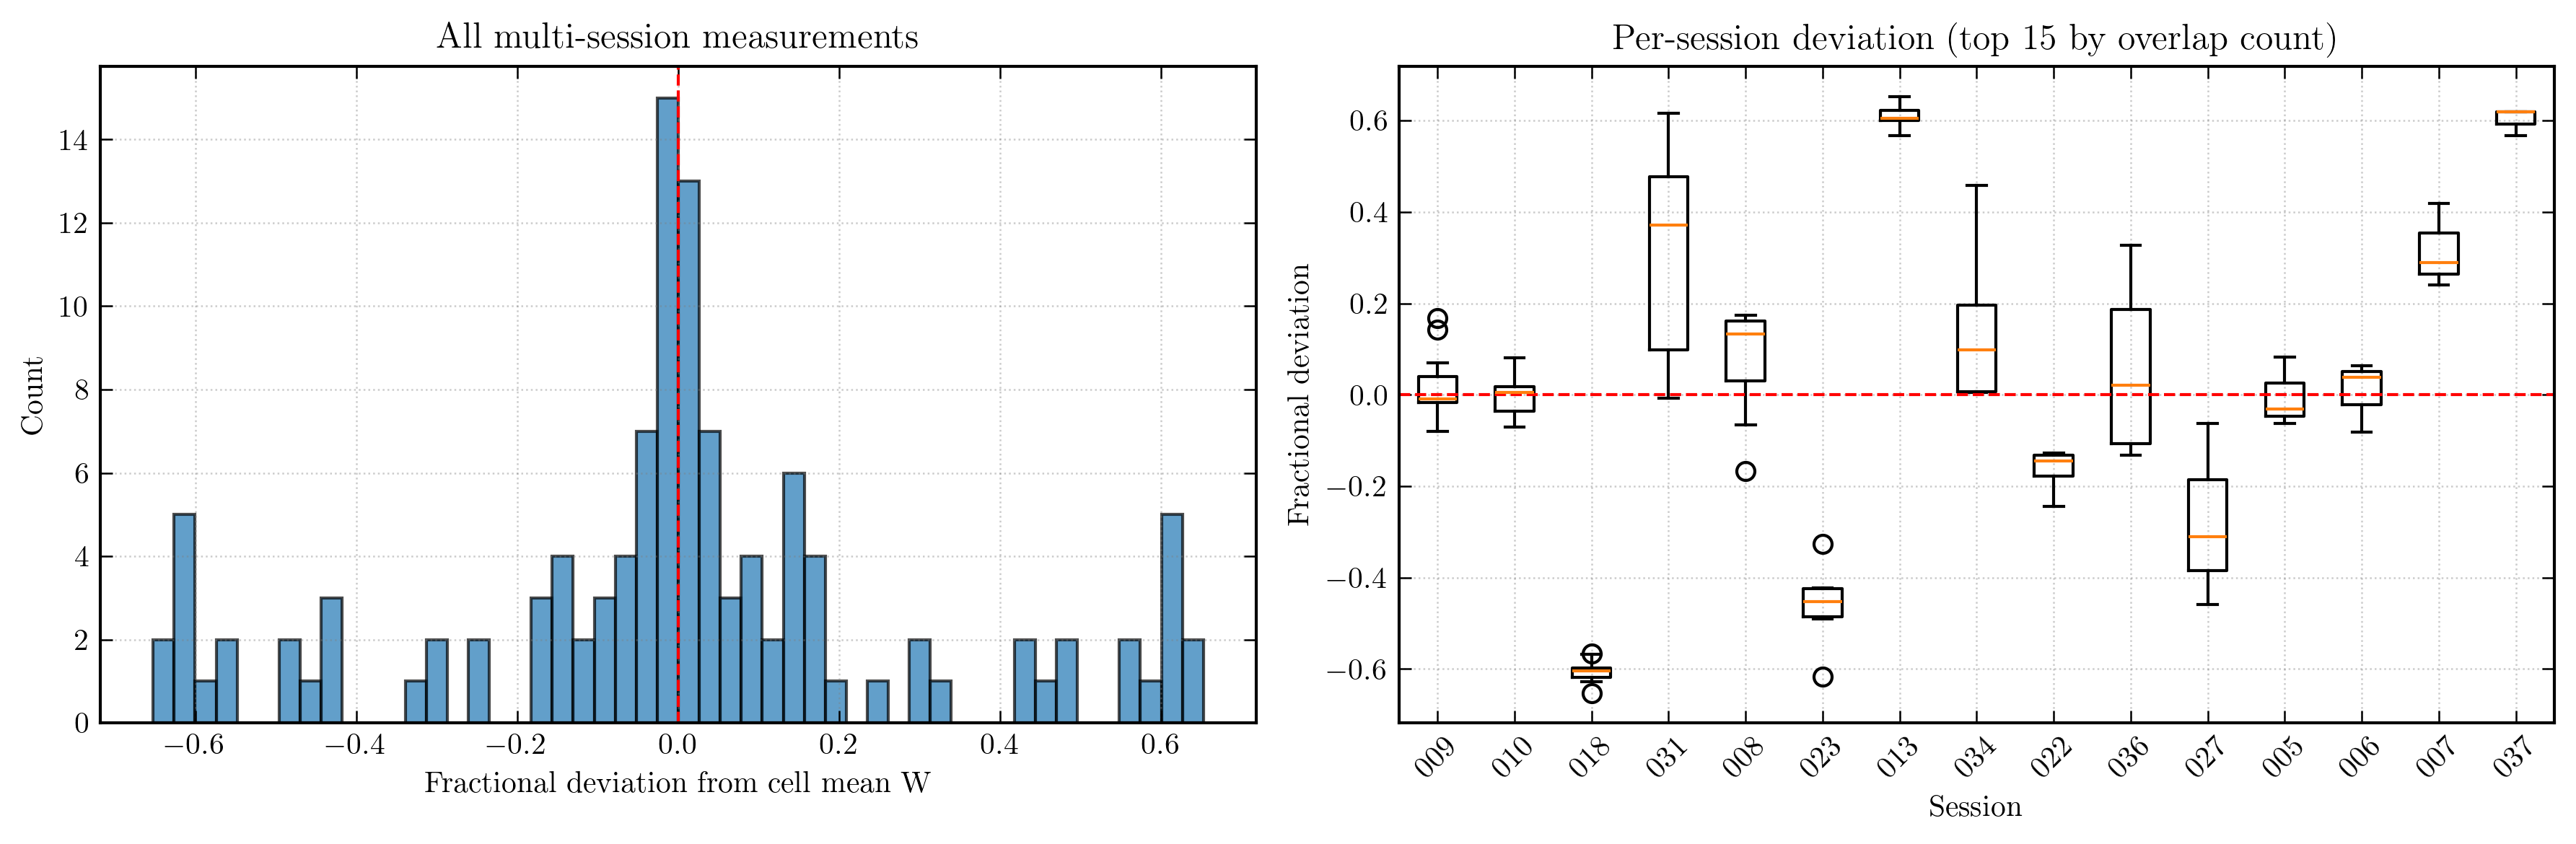

In [32]:
# Find cells observed in 2+ sessions and compare their calibrated T_B
multi_session_cells = defaultdict(list)
for (dr, gl, gb) in cell_results_TB:
    multi_session_cells[(gl, gb)].append(dr)
multi_session_cells = {k: v for k, v in multi_session_cells.items() if len(v) >= 2}

print(f'{len(multi_session_cells)} cells observed in 2+ sessions')

# For each multi-session cell, compute the integrated W per session
# and the fractional deviation from the cell mean
cross_rows = []
for (gl, gb), dr_list in multi_session_cells.items():
    W_per_session = {}
    for dr in dr_list:
        TB = cell_results_TB[(dr, gl, gb)]['T_B_overlap']
        W_per_session[dr] = np.nansum(TB) * dv_kms

    W_mean = np.mean(list(W_per_session.values()))
    if W_mean == 0:
        continue

    for dr, W_val in W_per_session.items():
        cross_rows.append({
            'gl': gl, 'gb': gb, 'session': dr,
            'W_K': W_val,
            'W_mean': W_mean,
            'frac_dev': (W_val - W_mean) / abs(W_mean),
            'T_sys': cell_results_TB[(dr, gl, gb)]['T_sys'],
        })

cross_df = pd.DataFrame(cross_rows)

if len(cross_df) > 0:
    # Per-session summary: median fractional deviation from multi-session mean
    session_dev = cross_df.groupby('session').agg(
        n_cells=('frac_dev', 'count'),
        median_frac_dev=('frac_dev', 'median'),
        mad_frac_dev=('frac_dev', lambda x: np.median(np.abs(x - np.median(x)))),
        median_T_sys=('T_sys', 'median'),
    ).reset_index()
    session_dev = session_dev.sort_values('median_frac_dev')
    session_dev['flag'] = session_dev['median_frac_dev'].apply(
        lambda x: '** LOW **' if x < -0.3 else ('* HIGH *' if x > 0.3 else ''))

    display(session_dev.style.format({
        'median_frac_dev': '{:+.2f}',
        'mad_frac_dev': '{:.2f}',
        'median_T_sys': '{:.0f}',
    }).set_caption('Cross-session T_B consistency (multi-session cells)'))

    n_suspect = ((session_dev['median_frac_dev'].abs() > 0.3) &
                 (session_dev['n_cells'] >= 3)).sum()
    print(f'{n_suspect} sessions with |median frac dev| > 30% and 3+ overlap cells')

    # Plot histogram of fractional deviations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.hist(cross_df['frac_dev'], bins=50, edgecolor='k', alpha=0.7)
    ax1.axvline(0, color='red', ls='--', lw=1)
    ax1.set_xlabel('Fractional deviation from cell mean W')
    ax1.set_ylabel('Count')
    ax1.set_title('All multi-session measurements')

    # Per-session box plot (top 15 by count)
    top_sessions = session_dev.nlargest(15, 'n_cells')['session'].values
    box_data = [cross_df[cross_df['session'] == s]['frac_dev'].values
                for s in top_sessions]
    ax2.boxplot(box_data, labels=[s.replace('session_', '') for s in top_sessions],
                vert=True)
    ax2.axhline(0, color='red', ls='--', lw=1)
    ax2.set_xlabel('Session')
    ax2.set_ylabel('Fractional deviation')
    ax2.set_title('Per-session deviation (top 15 by overlap count)')
    ax2.tick_params(axis='x', rotation=45)

    fig.tight_layout()
    plt.show()
else:
    print('No multi-session cells found for cross-check')

## 6. LSR correction and combine sessions

Shift each session's T_B spectrum to the LSR frame, then average
across sessions for each cell.

In [22]:
# Compute LSR corrections per (session, cell)
print('Computing LSR corrections...')
cell_dr_groups = defaultdict(list)
for r in records:
    if r.get('gl') is None or r['noise_on']:
        continue
    cell_dr_groups[(r['session'], r['gl'], r['gb'])].append(r)

session_cell_vcorr = {}
for key, group in cell_dr_groups.items():
    r0 = group[0]
    mean_t = np.mean([r['time'] for r in group])
    session_cell_vcorr[key] = vlsr_correction(r0['ra'], r0['dec'], mean_t)

sci_vcorr = list(session_cell_vcorr.values())
mean_vcorr = np.mean(sci_vcorr)
v_lsr_overlap = v_overlap + mean_vcorr

print(f'v_corr range: {min(sci_vcorr):.2f} to {max(sci_vcorr):.2f} km/s '
      f'(mean {mean_vcorr:.2f})')
print(f'Velocity (LSR): [{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s')

# Combine per-session T_B spectra onto common LSR grid.
# v_overlap is monotonically decreasing (velocity convention), so flip
# to increasing before np.interp and flip back after.
cell_combined = {}

cell_sessions = defaultdict(list)
for (dr, gl, gb) in cell_results_TB:
    cell_sessions[(gl, gb)].append(dr)

v_lsr_inc = v_lsr_overlap[::-1]

for (gl, gb), dr_list in cell_sessions.items():
    TB_all = []
    tsys_all = []
    npairs_total = 0

    for dr in dr_list:
        res = cell_results_TB[(dr, gl, gb)]
        v_corr = session_cell_vcorr.get((dr, gl, gb), 0.0)
        v_shifted = v_overlap + v_corr

        TB_interp = np.interp(v_lsr_inc, v_shifted[::-1],
                              res['T_B_overlap'][::-1],
                              left=np.nan, right=np.nan)[::-1]
        TB_all.append(TB_interp)
        tsys_all.append(res['T_sys'])
        npairs_total += res['n_pairs']

    TB_mean = np.nanmean(TB_all, axis=0)
    cell_combined[(gl, gb)] = {
        'T_B': TB_mean,
        'T_sys': np.mean(tsys_all),
        'n_pairs': npairs_total,
    }

# Sanity check
n_valid = sum(1 for v in cell_combined.values()
              if np.count_nonzero(np.isfinite(v['T_B'])) >= 8)
print(f'Combined (LSR): {len(cell_combined)} cells ({n_valid} with >=8 valid channels)')

Computing LSR corrections...
v_corr range: -43.89 to 43.33 km/s (mean -13.66)
Velocity (LSR): [-143, 77] km/s
Combined (LSR): 1636 cells (1636 with >=8 valid channels)


/tmp/ipykernel_25212/3092332479.py:51: RuntimeWarning: Mean of empty slice
  TB_mean = np.nanmean(TB_all, axis=0)


## 7. Neighbor-based QA (on T_B)

In [23]:
# Wrap cell_combined into the format expected by compute_cell_metrics:
# dict[(gl,gb)] -> {'R_overlap': array, 'n_pairs': int}
# The QA code uses 'R_overlap' as the key; here it contains T_B values.
cell_for_qa = {
    k: {'R_overlap': v['T_B'], 'n_pairs': v['n_pairs']}
    for k, v in cell_combined.items()
}

cell_metrics = compute_cell_metrics(cell_for_qa, v_lsr_overlap, dv_kms)
neighbor_cells = neighbor_qa(cell_metrics, dv_kms=dv_kms)

neighbor_flagged = [c for c in neighbor_cells if c['W_flag'] or c['peak_v_flag']]
n_W_flag = sum(1 for c in neighbor_cells if c['W_flag'])
n_pv_flag = sum(1 for c in neighbor_cells if c['peak_v_flag'])

print(f'Neighbor QA: {len(neighbor_cells)} cells analyzed')
print(f'  Flags: W={n_W_flag}, peak_v={n_pv_flag}, any={len(neighbor_flagged)}')

if neighbor_flagged:
    print('  Most deviant cells:')
    def severity(cell):
        w = abs(cell['W_frac_resid']) if np.isfinite(cell['W_frac_resid']) else 0.0
        v = abs(cell['peak_v_z']) if np.isfinite(cell['peak_v_z']) else 0.0
        return max(w, v)
    for cell in sorted(neighbor_flagged, key=severity, reverse=True)[:12]:
        print(f"    l={cell['gl']:3d} b={cell['gb']:3d} "
              f"W={cell['W']:+.1f} (frac={cell['W_frac_resid']:+.2f}, z={cell['W_z']:+.2f}) "
              f"v_peak={cell['peak_v']:+.1f} km/s "
              f"(dv={cell['peak_v_resid']:+.1f}, z={cell['peak_v_z']:+.2f}) "
              f"n={cell['neighbor_count']}")

Neighbor QA: 1636 cells analyzed
  Flags: W=18, peak_v=9, any=27
  Most deviant cells:
    l=125 b=  1 W=+5274.5 (frac=+0.17, z=+0.80) v_peak=-55.9 km/s (dv=-39.4, z=-9.80) n=33
    l=114 b= -1 W=+4104.3 (frac=+0.03, z=+0.63) v_peak=-47.4 km/s (dv=-19.1, z=-6.38) n=53
    l= 46 b=  0 W=+1344.5 (frac=+0.11, z=+0.71) v_peak=+56.0 km/s (dv=+36.8, z=+6.19) n=20
    l=208 b=  0 W=+5278.6 (frac=+0.16, z=+2.30) v_peak=+41.7 km/s (dv=+23.4, z=+5.96) n=36
    l=231 b= -3 W=+3554.1 (frac=-0.06, z=-0.36) v_peak=+41.2 km/s (dv=+20.9, z=+5.65) n=24
    l=128 b= 16 W=+260.9 (frac=+0.13, z=+6.66) v_peak=-12.6 km/s (dv=-16.5, z=-5.49) n=6
    l=123 b=  1 W=+5945.7 (frac=+0.30, z=+1.39) v_peak=-55.9 km/s (dv=-38.9, z=-5.31) n=34
    l=231 b=  1 W=+3529.0 (frac=-0.03, z=-0.16) v_peak=+51.2 km/s (dv=+24.5, z=+4.85) n=33
    l= 44 b=  0 W=+1383.4 (frac=+0.20, z=+2.18) v_peak=+57.6 km/s (dv=+37.8, z=+4.10) n=20
    l=266 b= 24 W=+2404.2 (frac=+1.92, z=+15.95) v_peak=-3.6 km/s (dv=+0.4, z=+0.13) n=15
    l=

## 8. Per-session spectra PDF

In [24]:
with PdfPages('spectra_per_session_TB.pdf') as pdf:
    for dr in sessions:
        dr_spectra = {(l, b): cell_results_TB[(d, l, b)]['T_B_overlap']
                      for (d, l, b) in cell_results_TB if d == dr}
        if not dr_spectra:
            continue
        result = plot_spectra_grid(v_overlap, dr_spectra,
                                   ncols=5,
                                   color='C0',
                                   title=f'{dr} -- {len(dr_spectra)} pointings (T_B)')
        figs = result if isinstance(result, list) else [result]
        for f in figs:
            pdf.savefig(f)
            plt.close(f)

print('Saved spectra_per_session_TB.pdf')

Saved spectra_per_session_TB.pdf


## 9. Save reduced data (in Kelvin)

In [25]:
REDUCED_PATH = Path('../reduced_survey_TB.npz')

cell_keys_arr = np.array(sorted(cell_combined.keys()), dtype=int)
TB_stack = np.array([cell_combined[(gl, gb)]['T_B']
                     for gl, gb in cell_keys_arr], dtype=float)
n_pairs_arr = np.array([cell_combined[(gl, gb)]['n_pairs']
                         for gl, gb in cell_keys_arr], dtype=int)
T_sys_arr = np.array([cell_combined[(gl, gb)]['T_sys']
                       for gl, gb in cell_keys_arr], dtype=float)

# QA flags
metrics_lookup = {(c['gl'], c['gb']): c for c in neighbor_cells}
metrics_keys = ['W', 'peak_R', 'peak_v', 'peak_prom', 'snr', 'noise_rms',
                'W_frac_resid', 'W_z', 'peak_v_resid', 'peak_v_z',
                'neighbor_count']
metrics_arrays = {}
for mk in metrics_keys:
    metrics_arrays[mk] = np.array(
        [metrics_lookup.get((gl, gb), {}).get(mk, np.nan)
         for gl, gb in cell_keys_arr], dtype=float)

W_flag = np.array([metrics_lookup.get((gl, gb), {}).get('W_flag', False)
                    for gl, gb in cell_keys_arr], dtype=bool)
peak_v_flag = np.array([metrics_lookup.get((gl, gb), {}).get('peak_v_flag', False)
                         for gl, gb in cell_keys_arr], dtype=bool)

np.savez_compressed(
    REDUCED_PATH,
    cell_keys=cell_keys_arr,
    TB_stack=TB_stack,
    v_lsr=v_lsr_overlap,
    dv_kms=dv_kms,
    n_pairs=n_pairs_arr,
    T_sys=T_sys_arr,
    W_flag=W_flag,
    peak_v_flag=peak_v_flag,
    **metrics_arrays,
)
print(f'Saved: {REDUCED_PATH}')
print(f'  {len(cell_keys_arr)} cells, {TB_stack.shape[1]} channels')
print(f'  QA flags: W={W_flag.sum()}, peak_v={peak_v_flag.sum()}')

Saved: ../reduced_survey_TB.npz
  1636 cells, 418 channels
  QA flags: W=18, peak_v=9


## 10. Science products

Reference spectrum, l-v diagrams, integrated intensity / peak T_B maps,
and channel maps -- all in Kelvin.

In [26]:
gl_arr = cell_keys_arr[:, 0].astype(float)
gb_arr = cell_keys_arr[:, 1].astype(float)
any_flag = W_flag | peak_v_flag
clean = ~any_flag

# Derived quantities
W_K = np.nansum(TB_stack, axis=1) * dv_kms
peak_TB = np.array([
    TB_stack[i, np.nanargmax(TB_stack[i])]
    if np.any(np.isfinite(TB_stack[i])) else np.nan
    for i in range(len(cell_keys_arr))
])
peak_v_arr = np.array([
    v_lsr_overlap[np.nanargmax(TB_stack[i])]
    if np.any(np.isfinite(TB_stack[i])) else np.nan
    for i in range(len(cell_keys_arr))
])

print(f'{clean.sum()} clean cells, {any_flag.sum()} flagged')

1609 clean cells, 27 flagged


T_sys = 139 K, peak T_B = 65.2 K


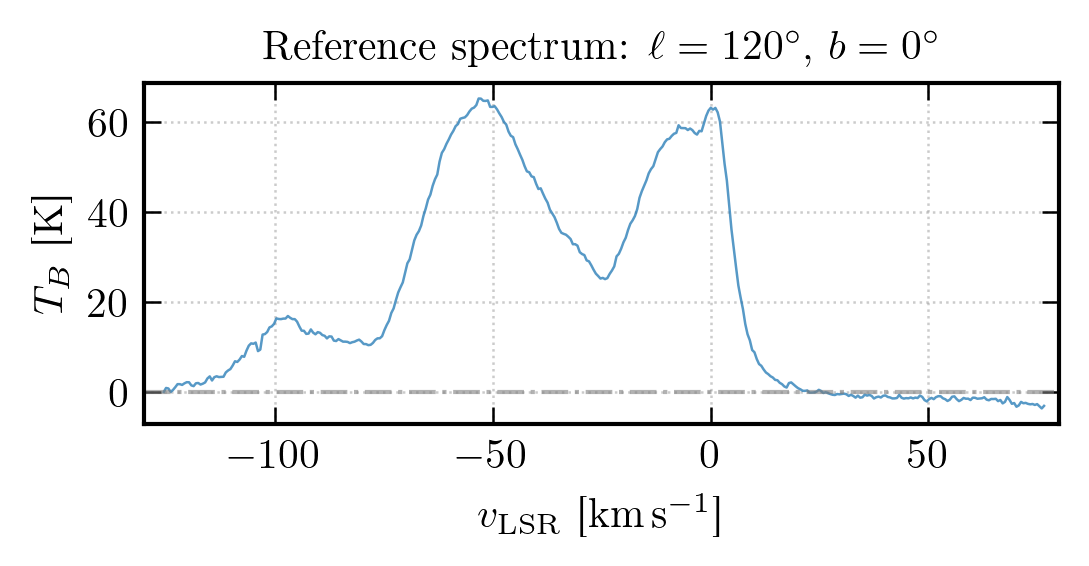

In [27]:
# --- Reference spectrum ---
ref_idx = np.where((cell_keys_arr[:, 0] == 120) & (cell_keys_arr[:, 1] == 0))[0]
if len(ref_idx) == 0:
    print('WARNING: (l=120, b=0) not found')
else:
    i = ref_idx[0]
    ax = plot_hi_spectrum(
        v_lsr_overlap, TB_stack[i],
        title=r'Reference spectrum: $\ell=120^\circ$, $b=0^\circ$',
        ylabel=r'$T_B$ [K]',
        xlabel=r'$v_{\mathrm{LSR}}$ [km\,s$^{-1}$]',
        color='C0', ax=None,
    )
    ax.set_xlim(-130, 80)
    print(f'T_sys = {T_sys_arr[i]:.0f} K, peak T_B = {peak_TB[i]:.1f} K')
    plt.show()

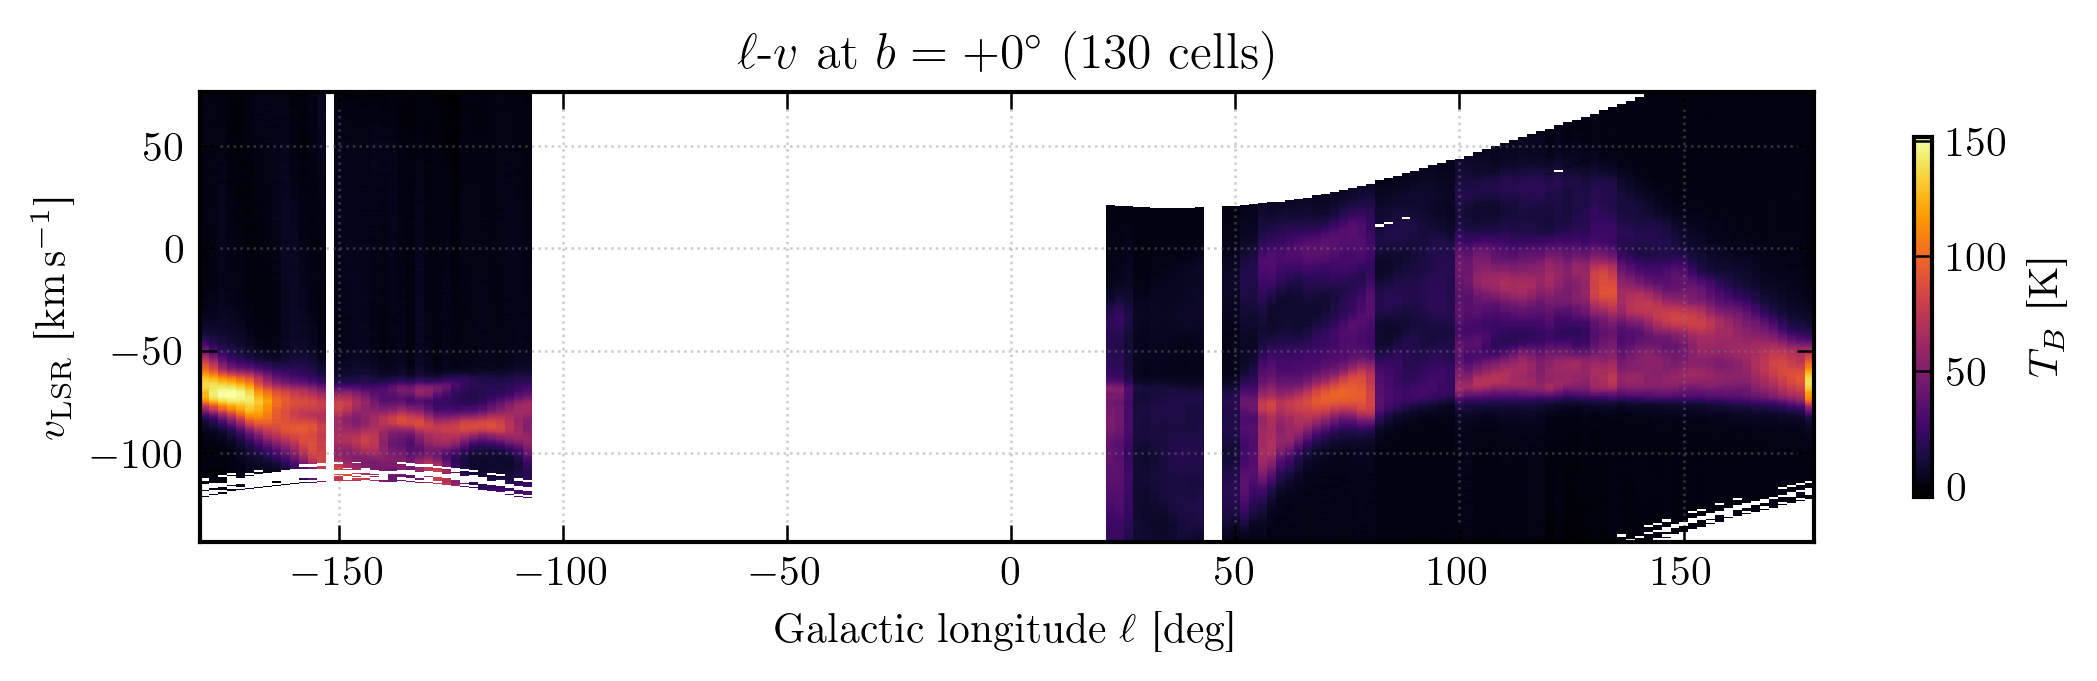

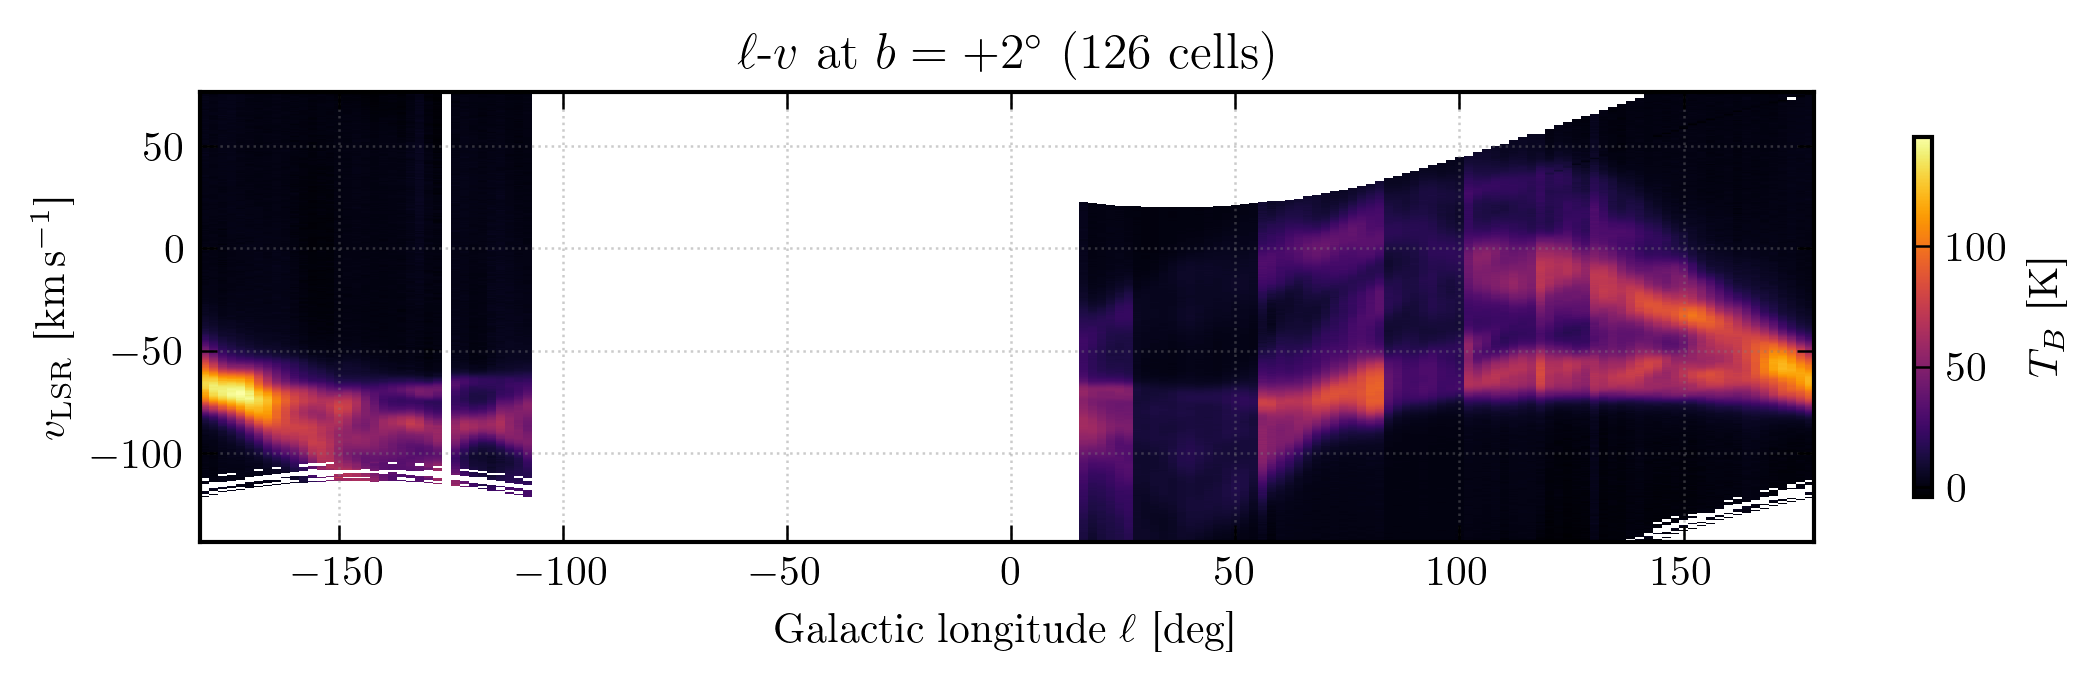

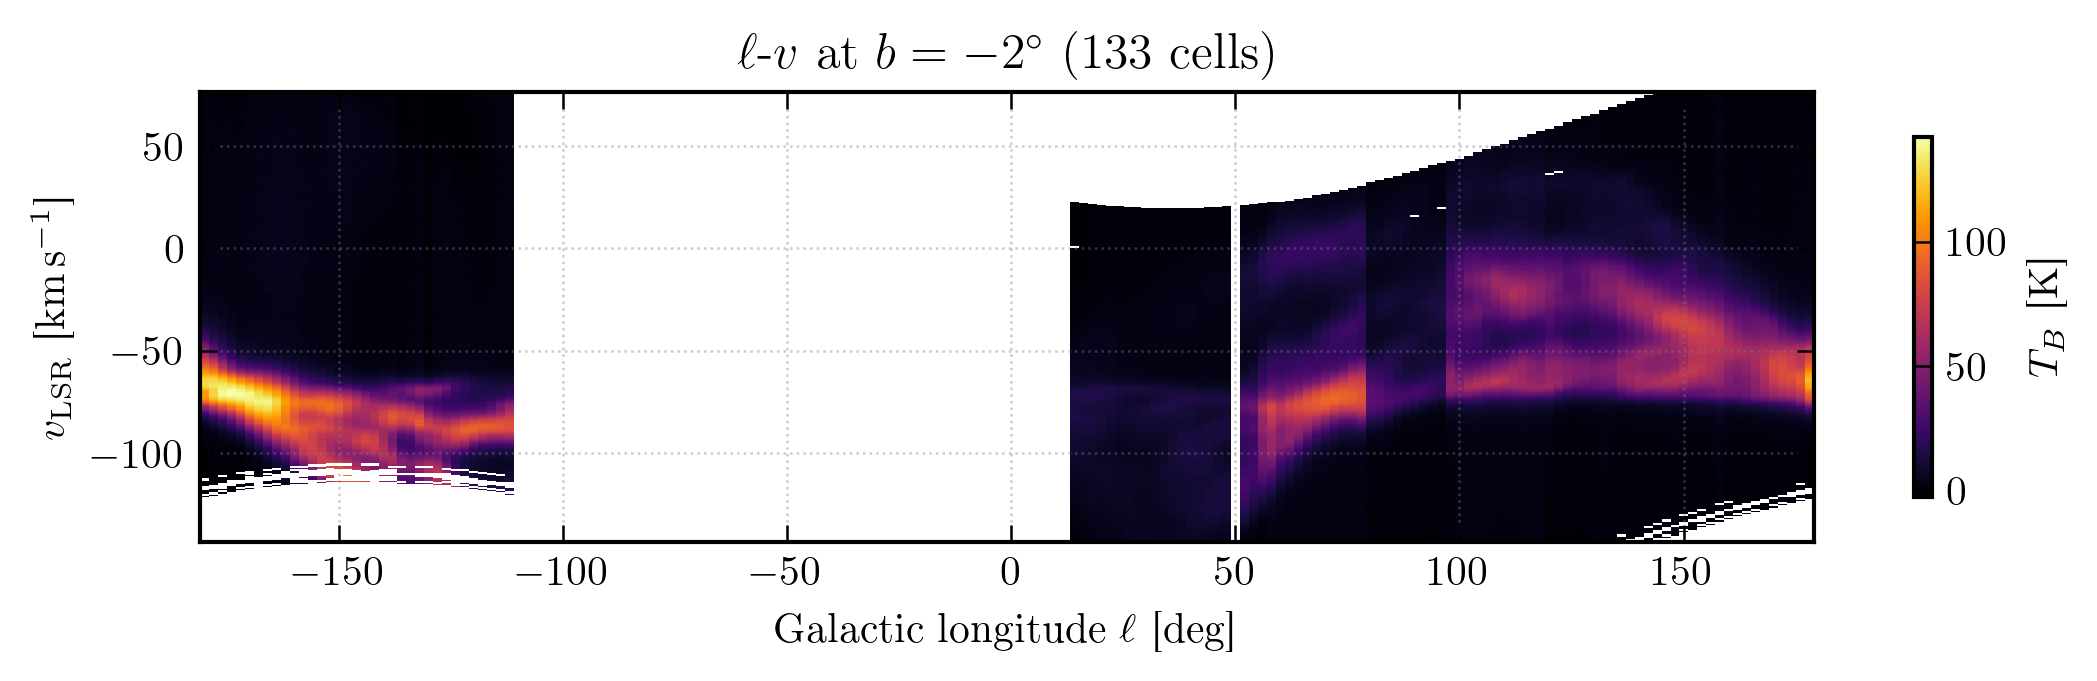

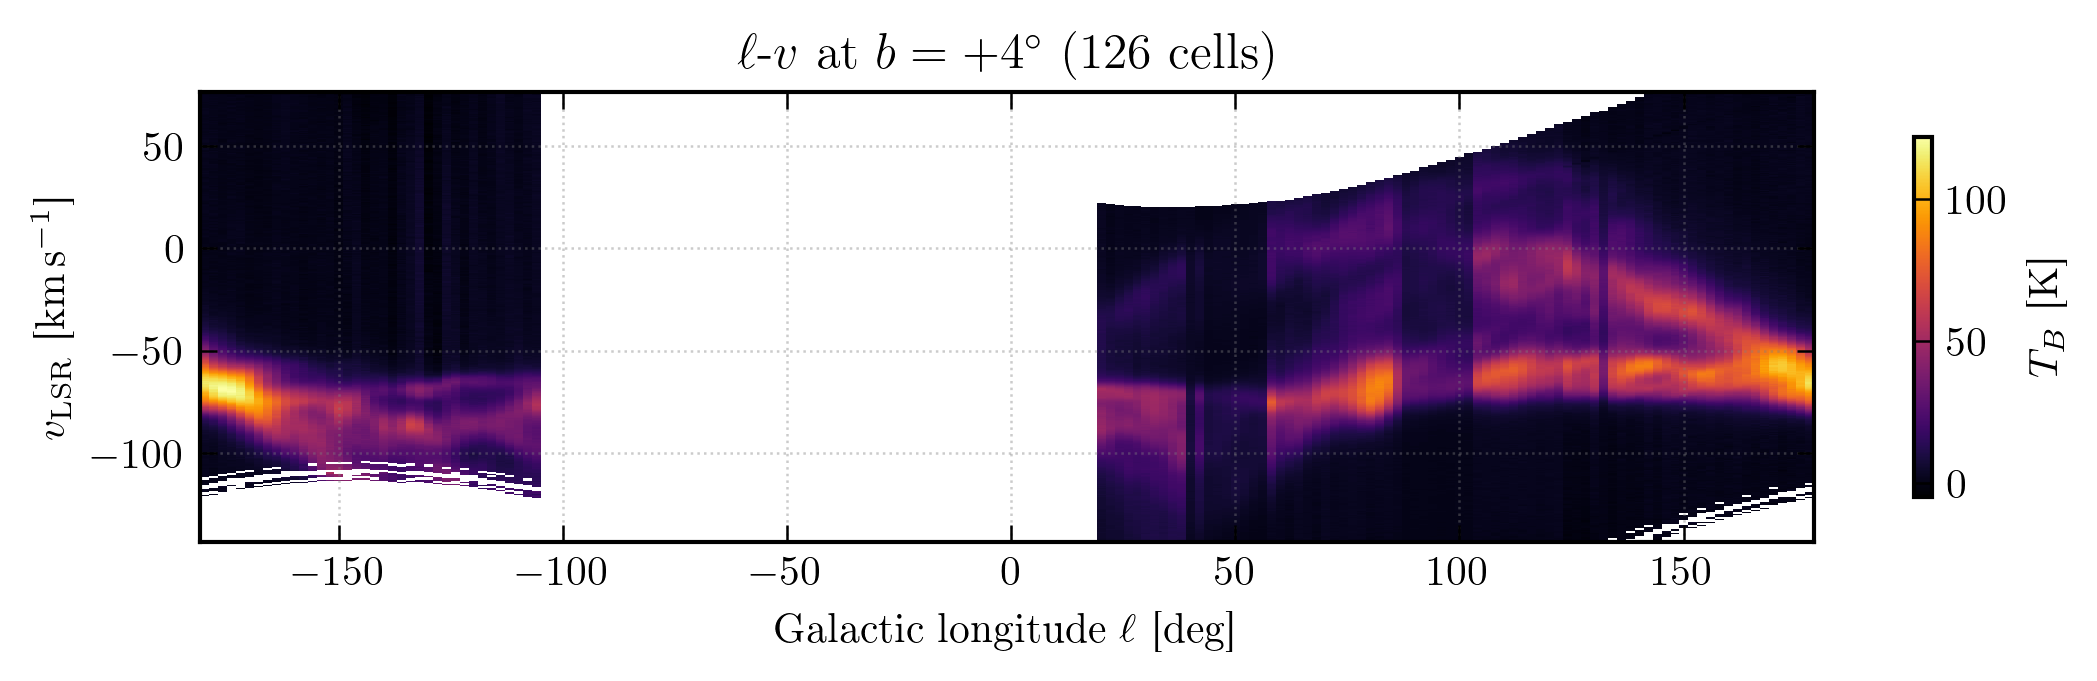

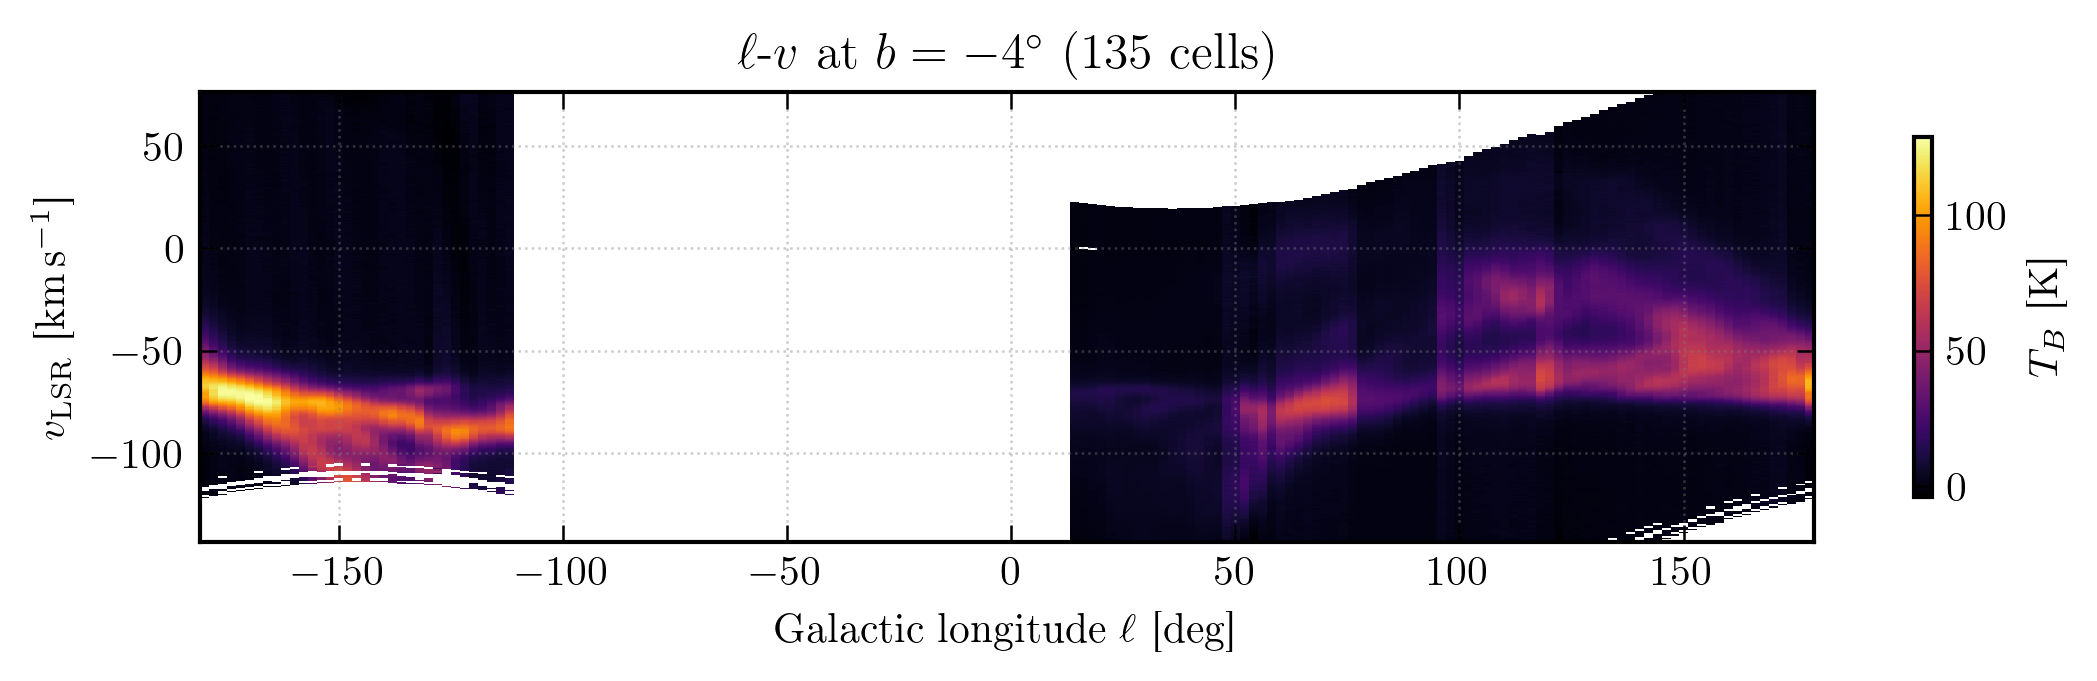

In [28]:
# --- l-v diagrams ---
b_cuts = [0, 2, -2, 4, -4]

for b_cut in b_cuts:
    sel = np.where((cell_keys_arr[:, 1] == b_cut) & clean)[0]
    if len(sel) < 3:
        continue

    l_wrapped = ((cell_keys_arr[sel, 0] + 180) % 360) - 180
    order = np.argsort(l_wrapped)
    sel = sel[order]
    l_wrapped = l_wrapped[order]

    l_unique = np.arange(l_wrapped.min(), l_wrapped.max() + 1, 2)
    lv_img = np.full((len(v_lsr_overlap), len(l_unique)), np.nan)
    for j, idx in enumerate(sel):
        li = np.searchsorted(l_unique, l_wrapped[j])
        if 0 <= li < len(l_unique):
            lv_img[:, li] = TB_stack[idx]

    fig, ax = plotting.textwidth_figure(5)
    im = ax.imshow(
        lv_img, origin='lower', aspect='auto',
        extent=[l_unique[0] - 1, l_unique[-1] + 1,
                v_lsr_overlap[-1], v_lsr_overlap[0]],
        cmap='inferno', interpolation='nearest',
    )
    ax.set_xlabel(r'Galactic longitude $\ell$ [deg]', fontsize=LABEL_SIZE)
    ax.set_ylabel(r'$v_{\mathrm{LSR}}$ [km\,s$^{-1}$]', fontsize=LABEL_SIZE)
    ax.set_title(rf'$\ell$-$v$ at $b = {b_cut:+d}^\circ$ '
                 rf'({len(sel)} cells)', fontsize=EMPHASIS_SIZE)
    plt.colorbar(im, ax=ax, label=r'$T_B$ [K]', shrink=0.8)
    plt.show()

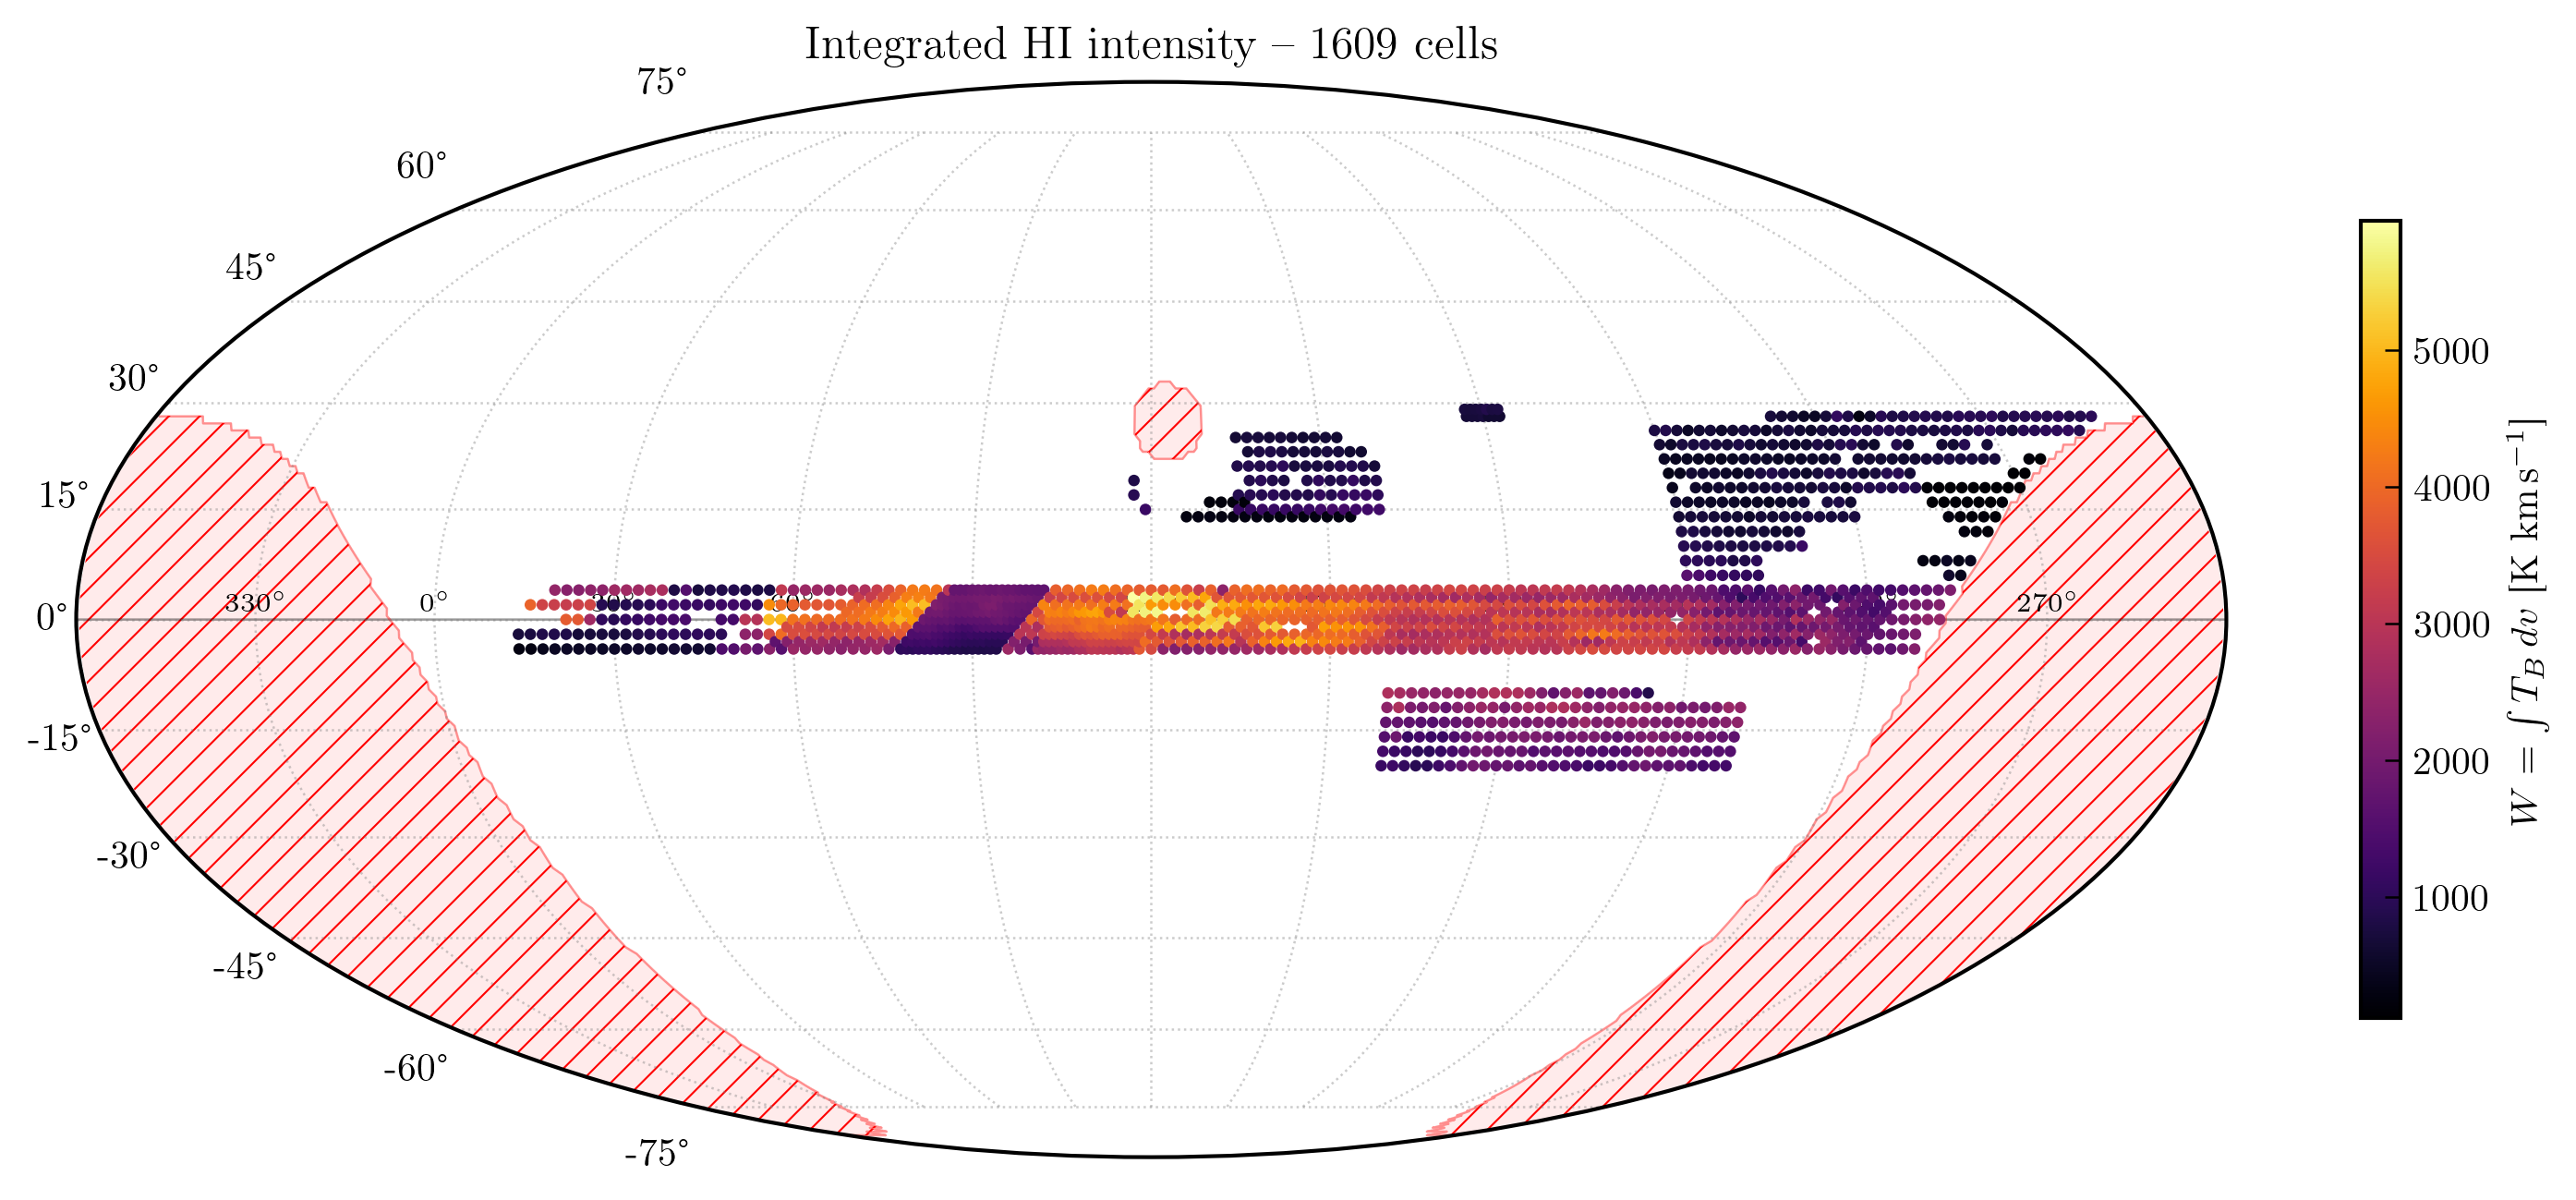

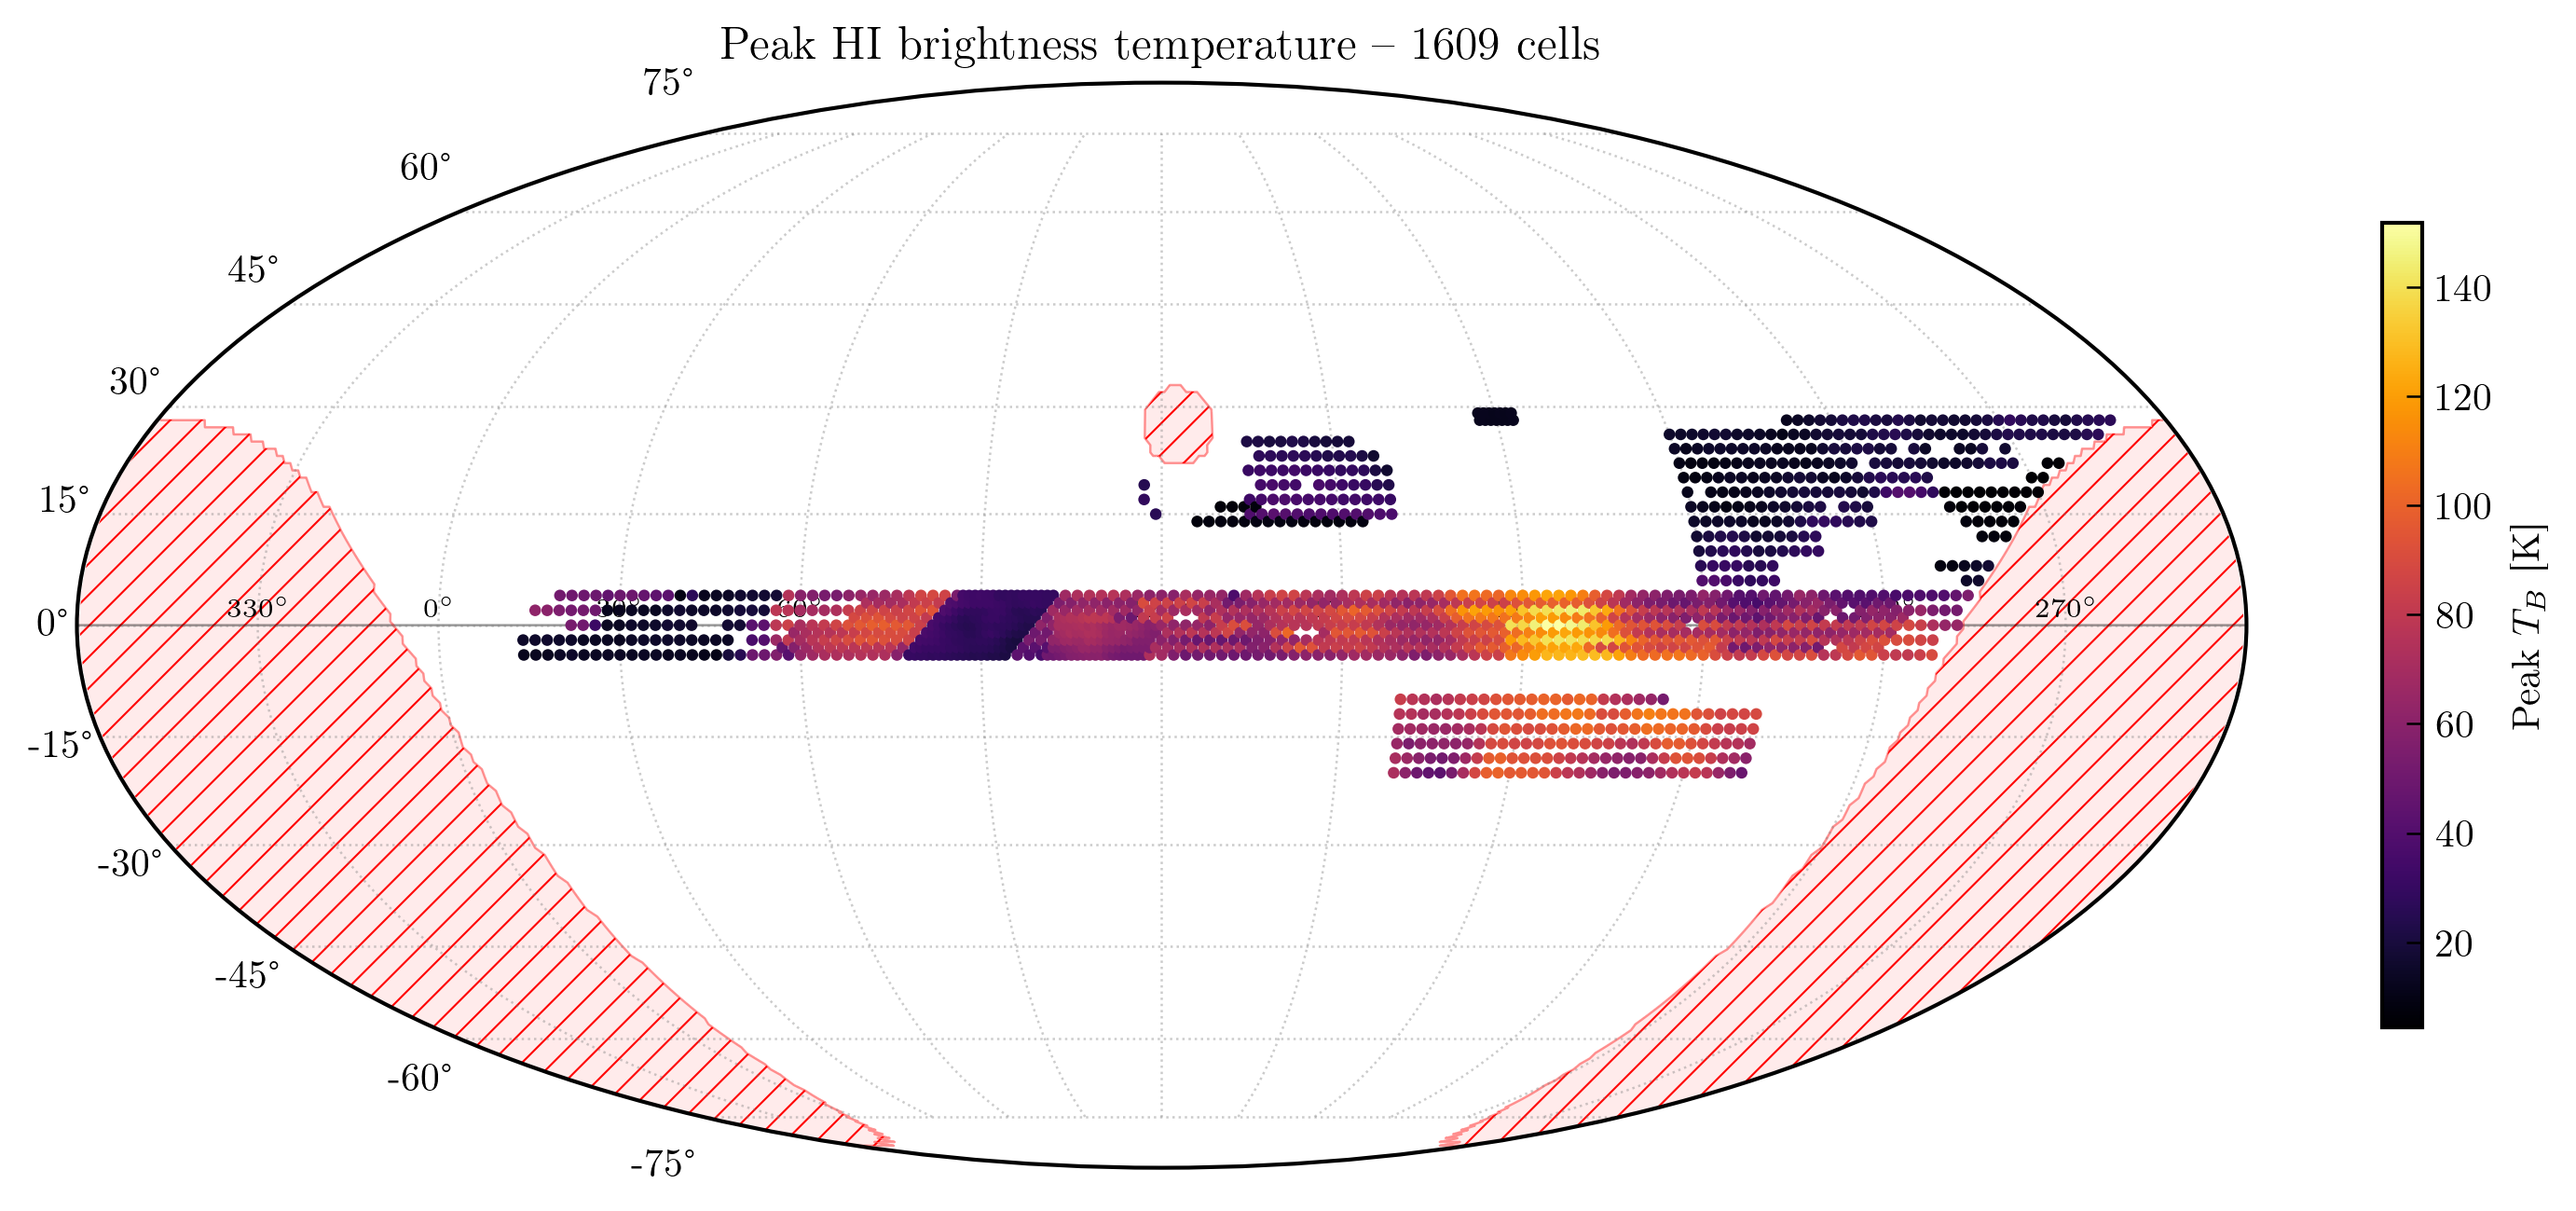

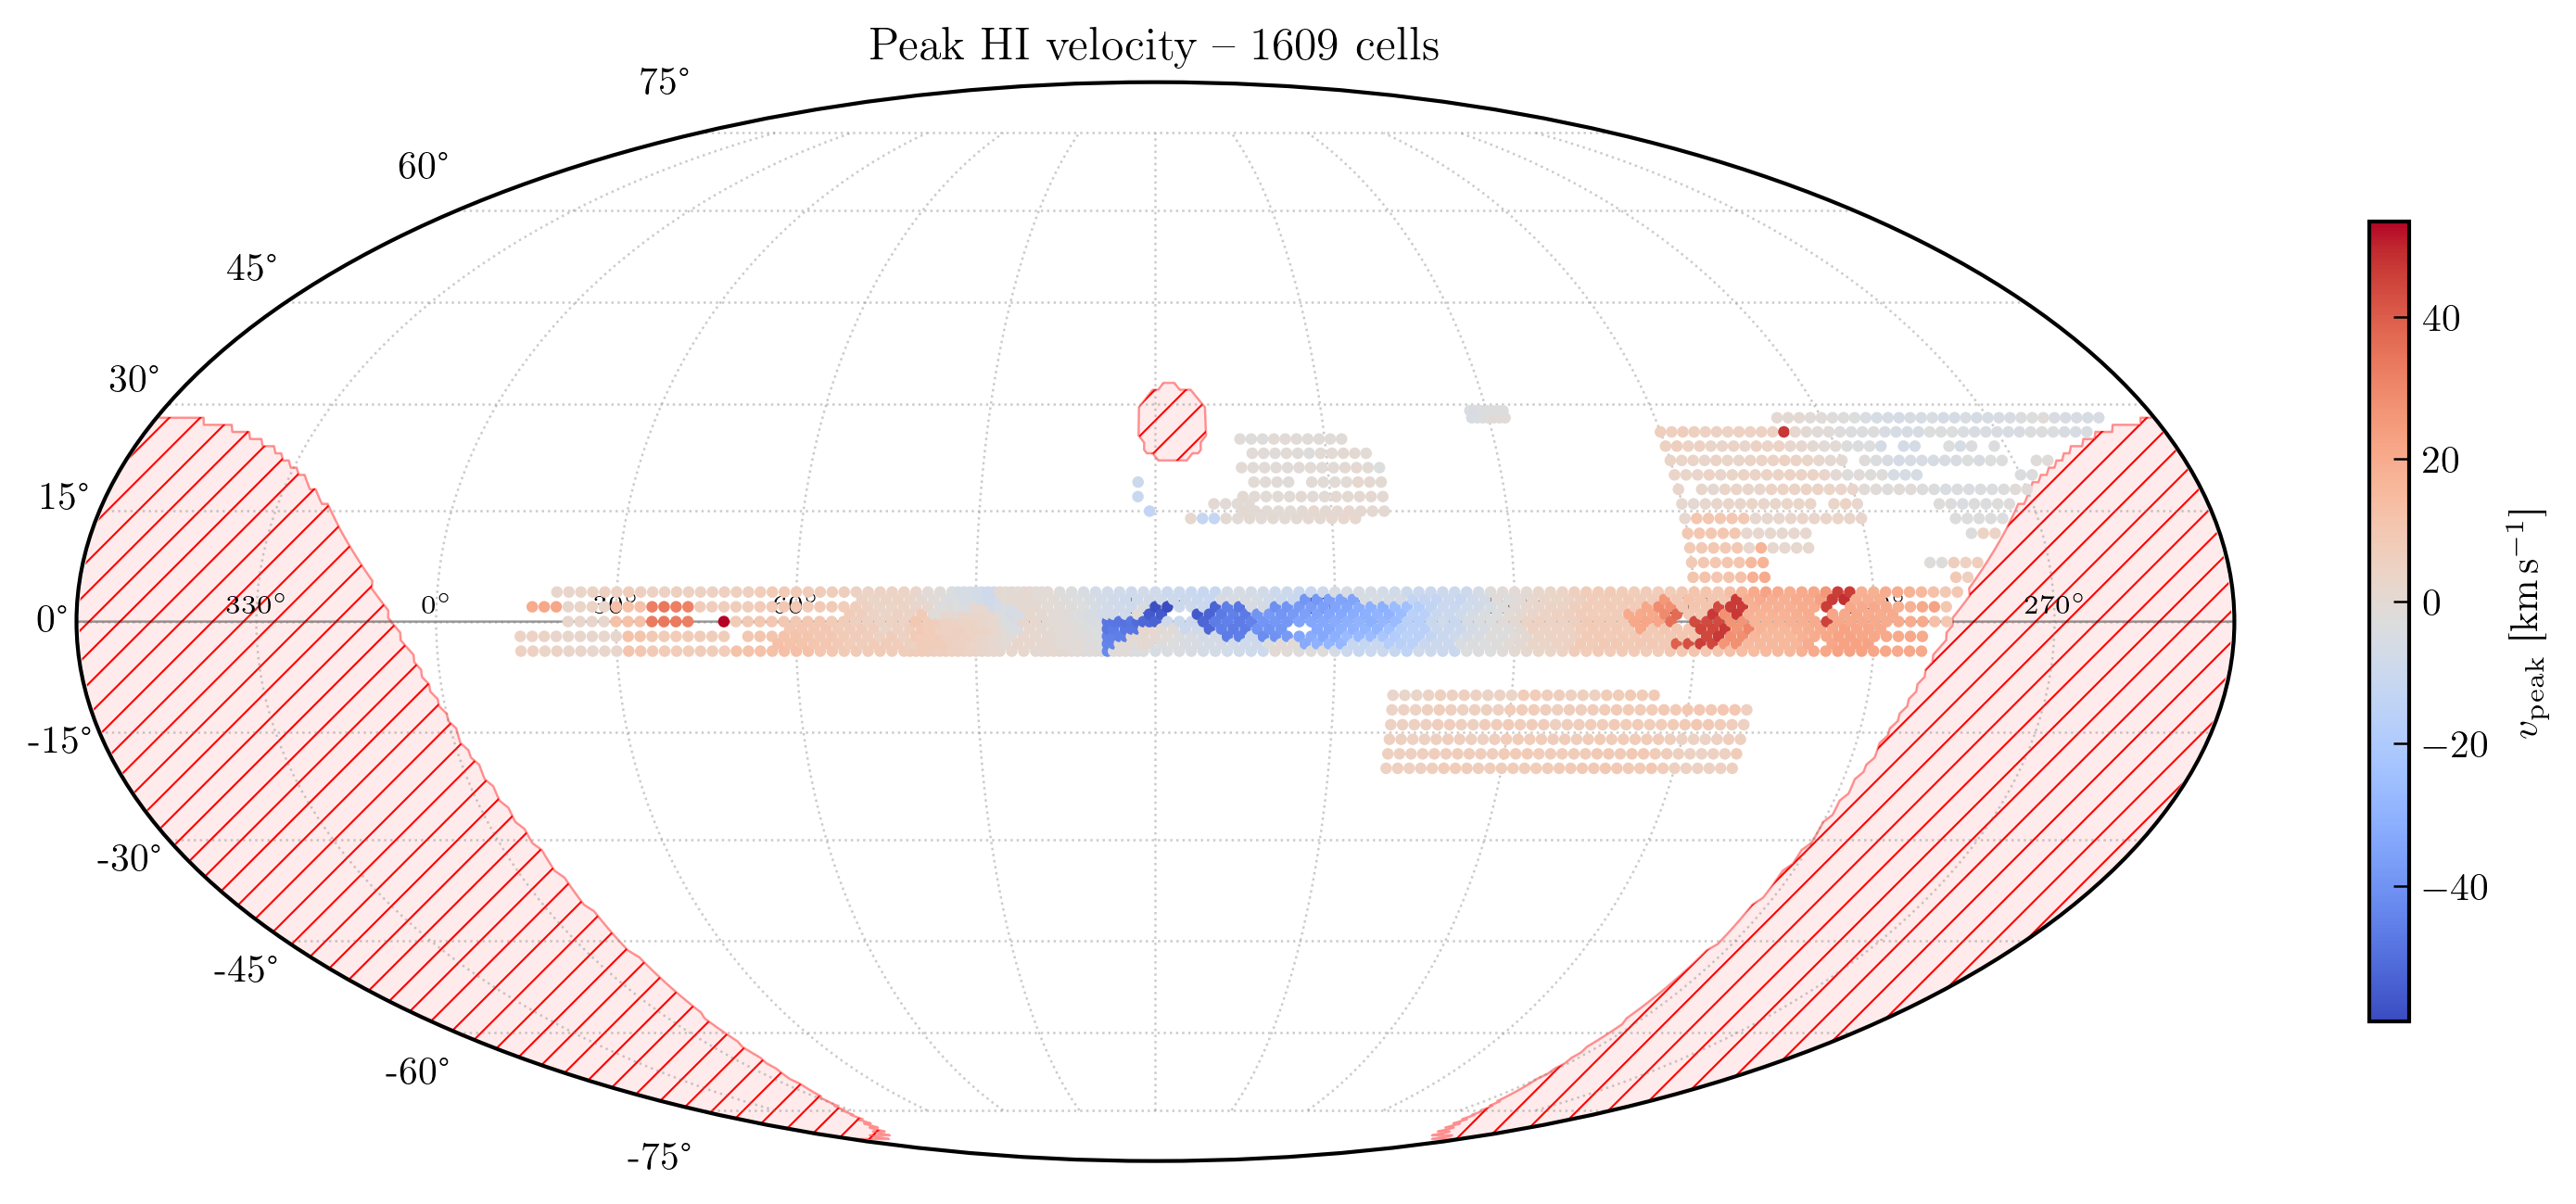

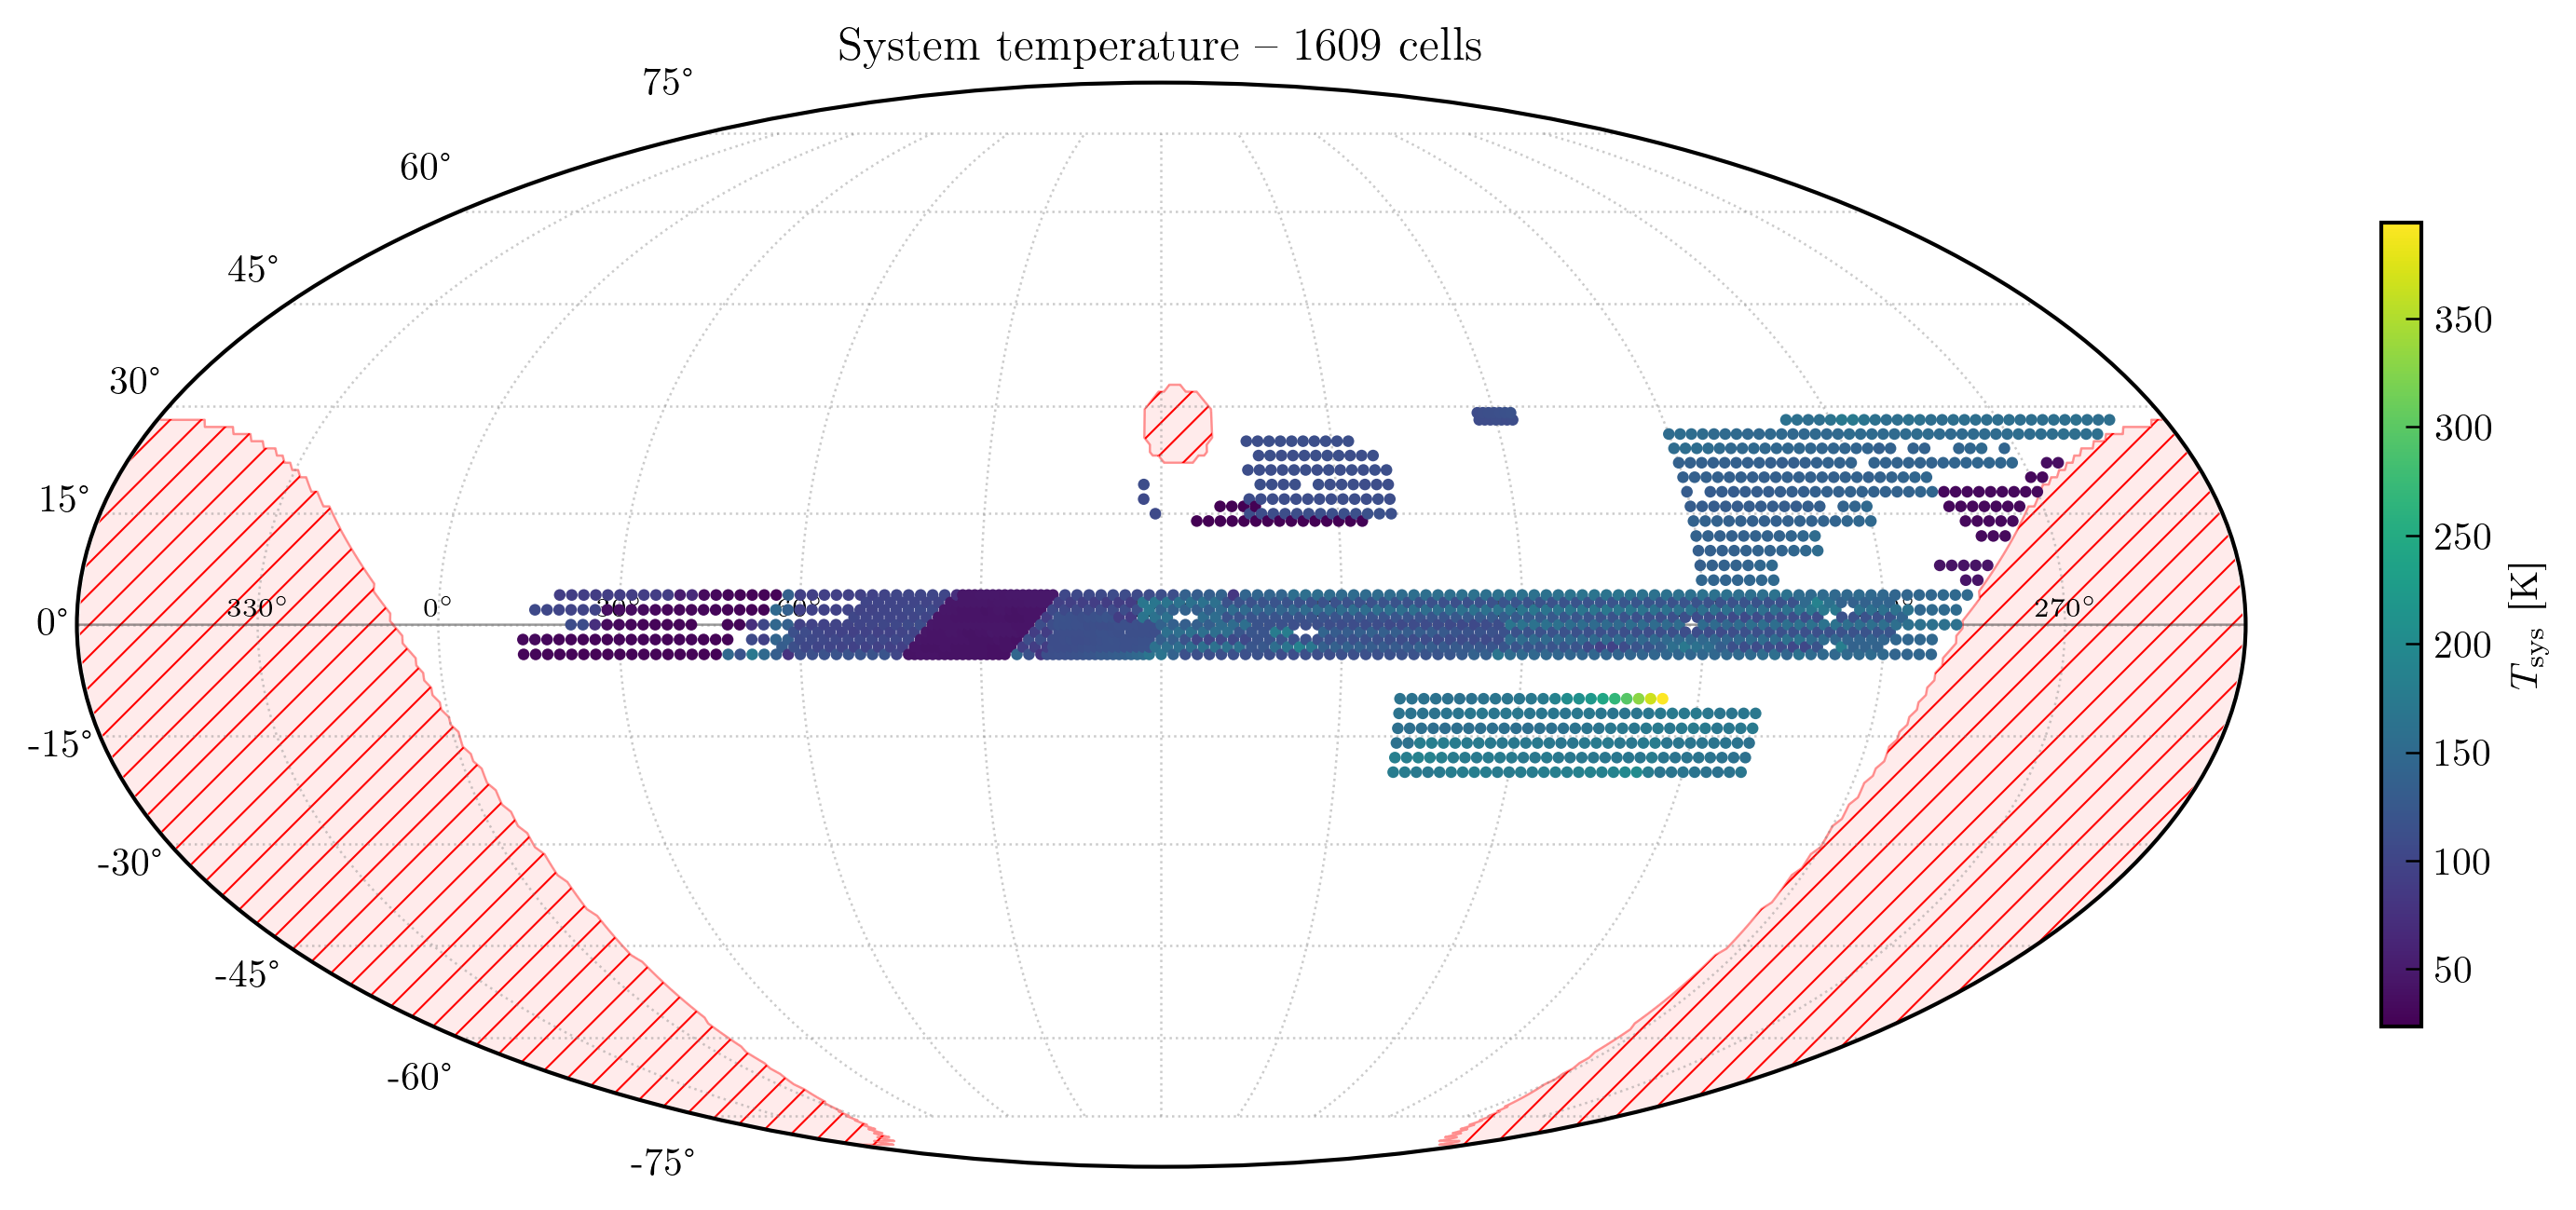

In [29]:
# --- Mollweide maps ---

# Integrated intensity W [K km/s]
fig, ax = plot_survey_mollweide(
    gl_arr[clean], gb_arr[clean], W_K[clean],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W = \int T_B \, dv$ [K km\,s$^{-1}$]',
    cmap='inferno', marker_size=SS_FINE,
    title=f'Integrated HI intensity -- {clean.sum()} cells',
)
plt.show()

# Peak brightness temperature
fig, ax = plot_survey_mollweide(
    gl_arr[clean], gb_arr[clean], peak_TB[clean],
    center_l=MOLL_CENTER_L,
    cbar_label=r'Peak $T_B$ [K]',
    cmap='inferno', marker_size=SS_FINE,
    title=f'Peak HI brightness temperature -- {clean.sum()} cells',
)
plt.show()

# Peak velocity
fig, ax = plot_survey_mollweide(
    gl_arr[clean], gb_arr[clean], peak_v_arr[clean],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$v_{\mathrm{peak}}$ [km\,s$^{-1}$]',
    cmap='coolwarm', marker_size=SS_FINE,
    title=f'Peak HI velocity -- {clean.sum()} cells',
)
plt.show()

# T_sys map
fig, ax = plot_survey_mollweide(
    gl_arr[clean], gb_arr[clean], T_sys_arr[clean],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$T_{\mathrm{sys}}$ [K]',
    cmap='viridis', marker_size=SS_FINE,
    title=f'System temperature -- {clean.sum()} cells',
)
plt.show()

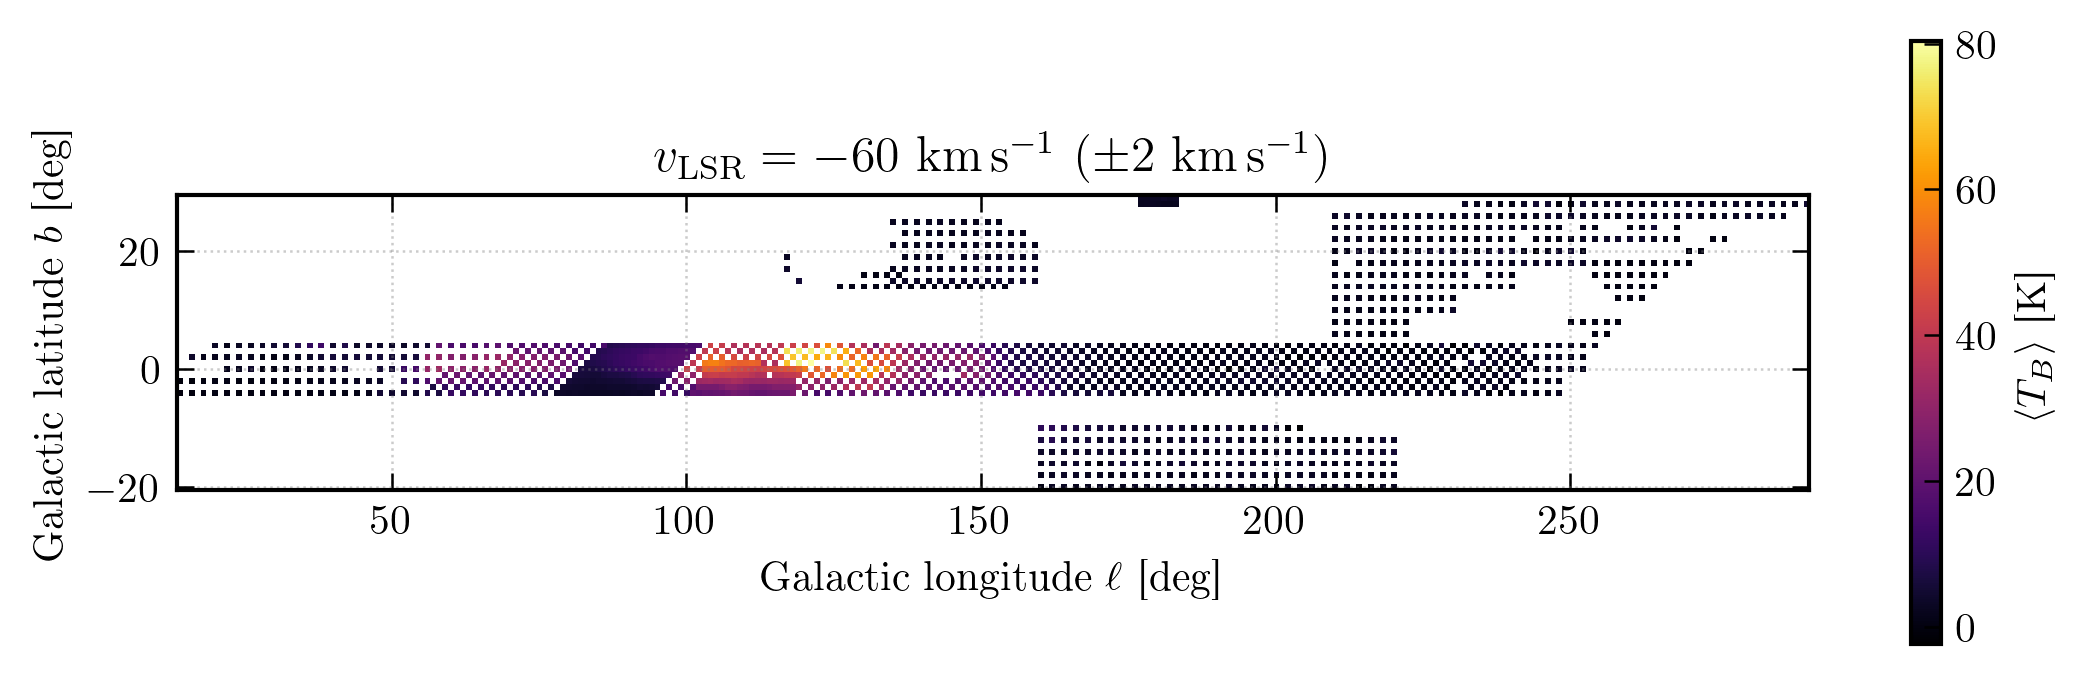

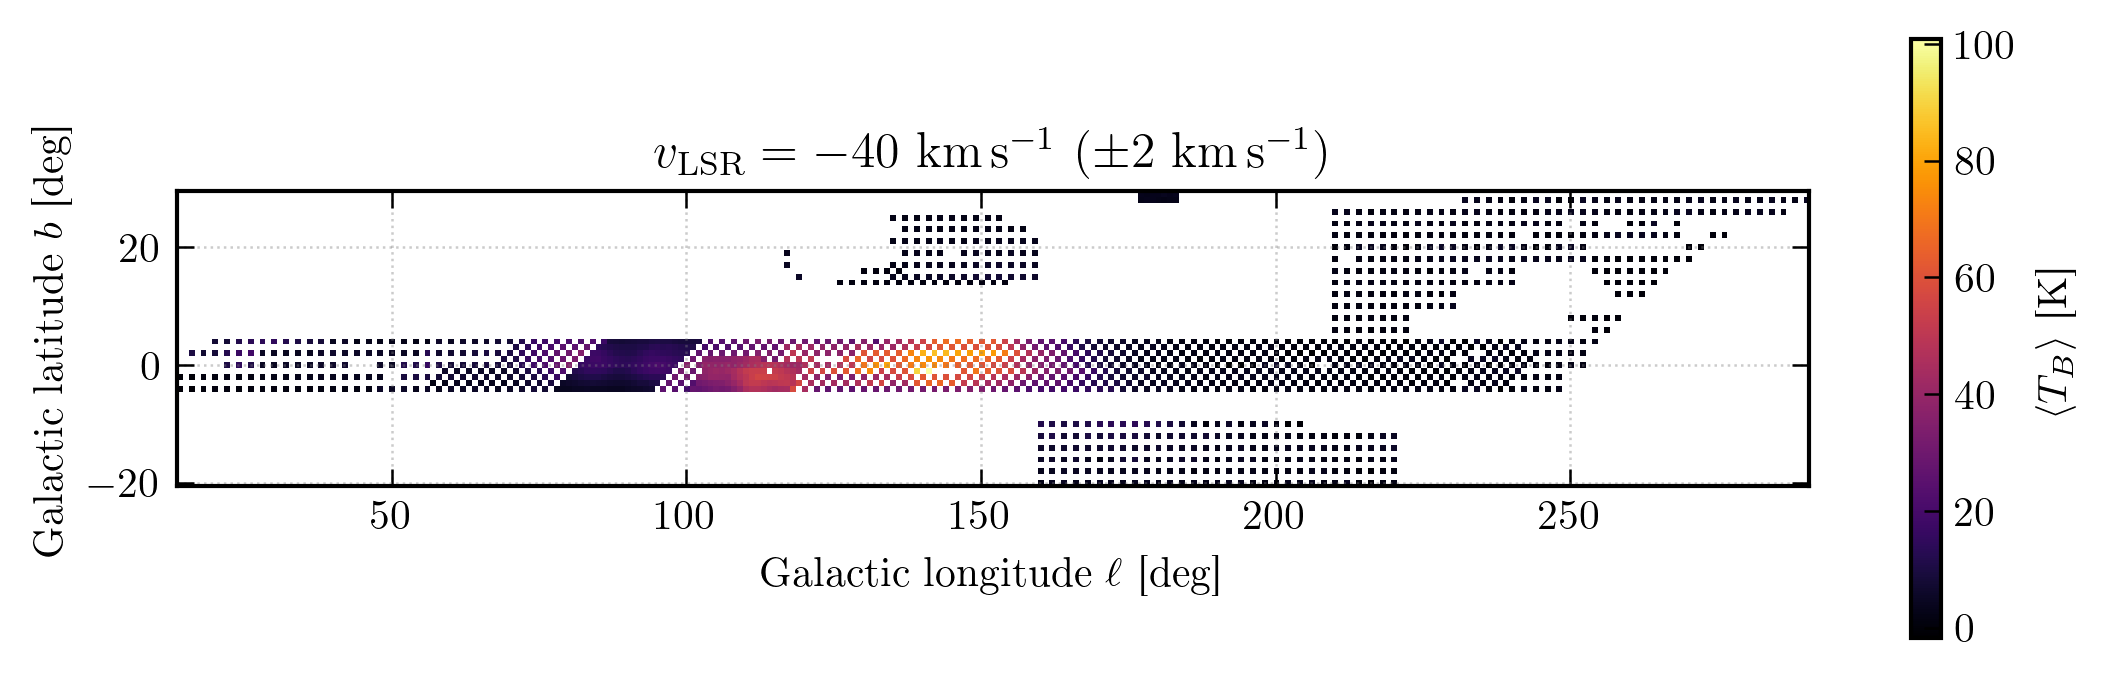

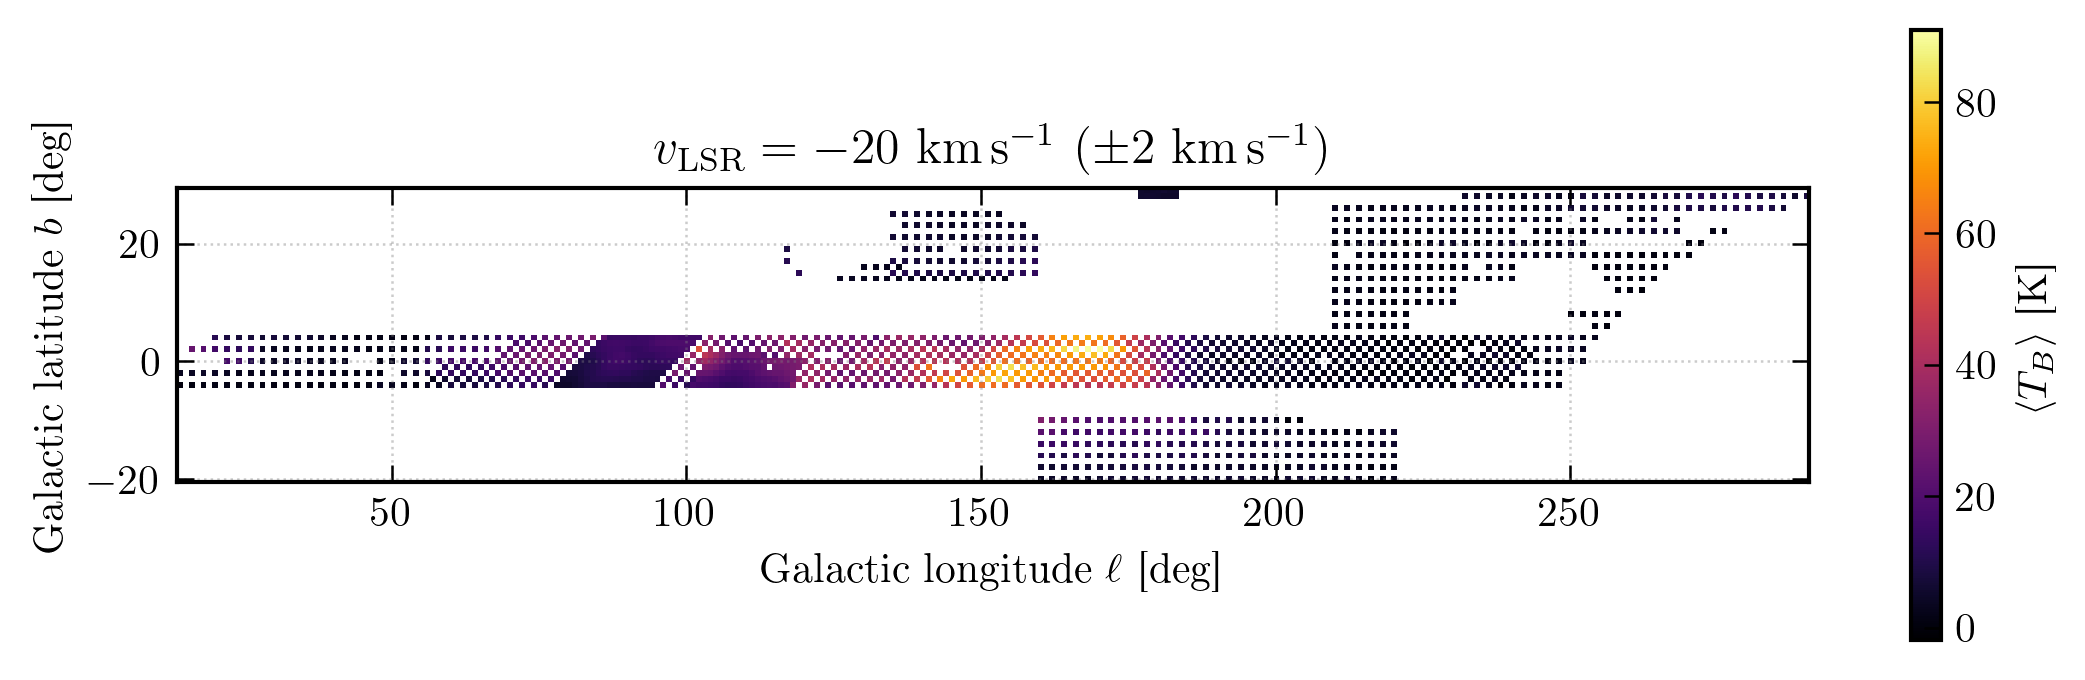

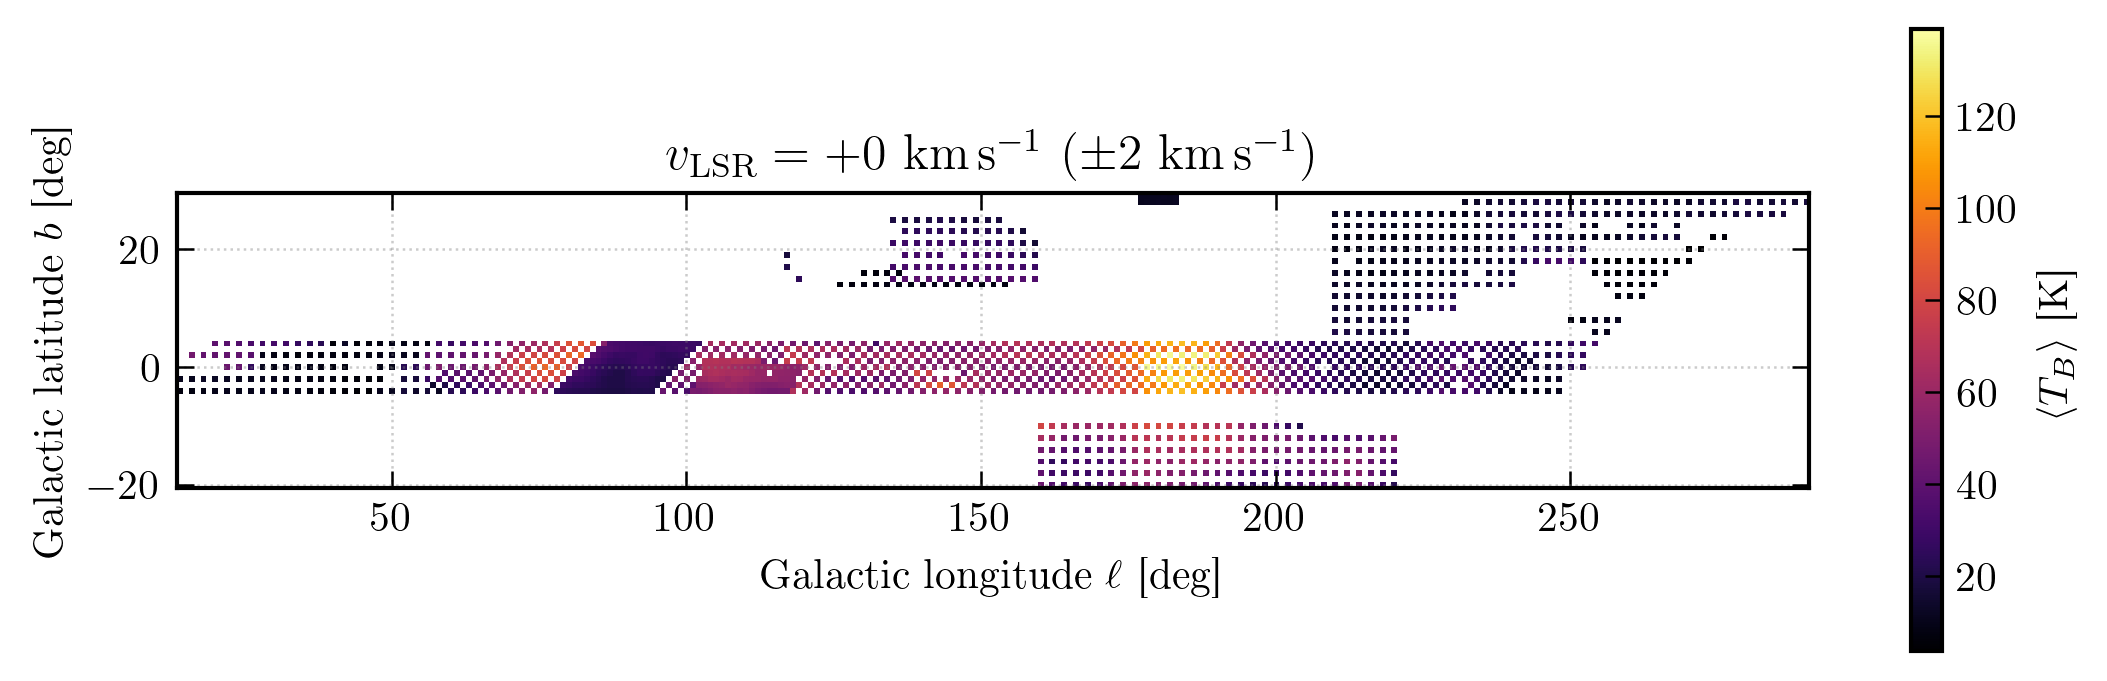

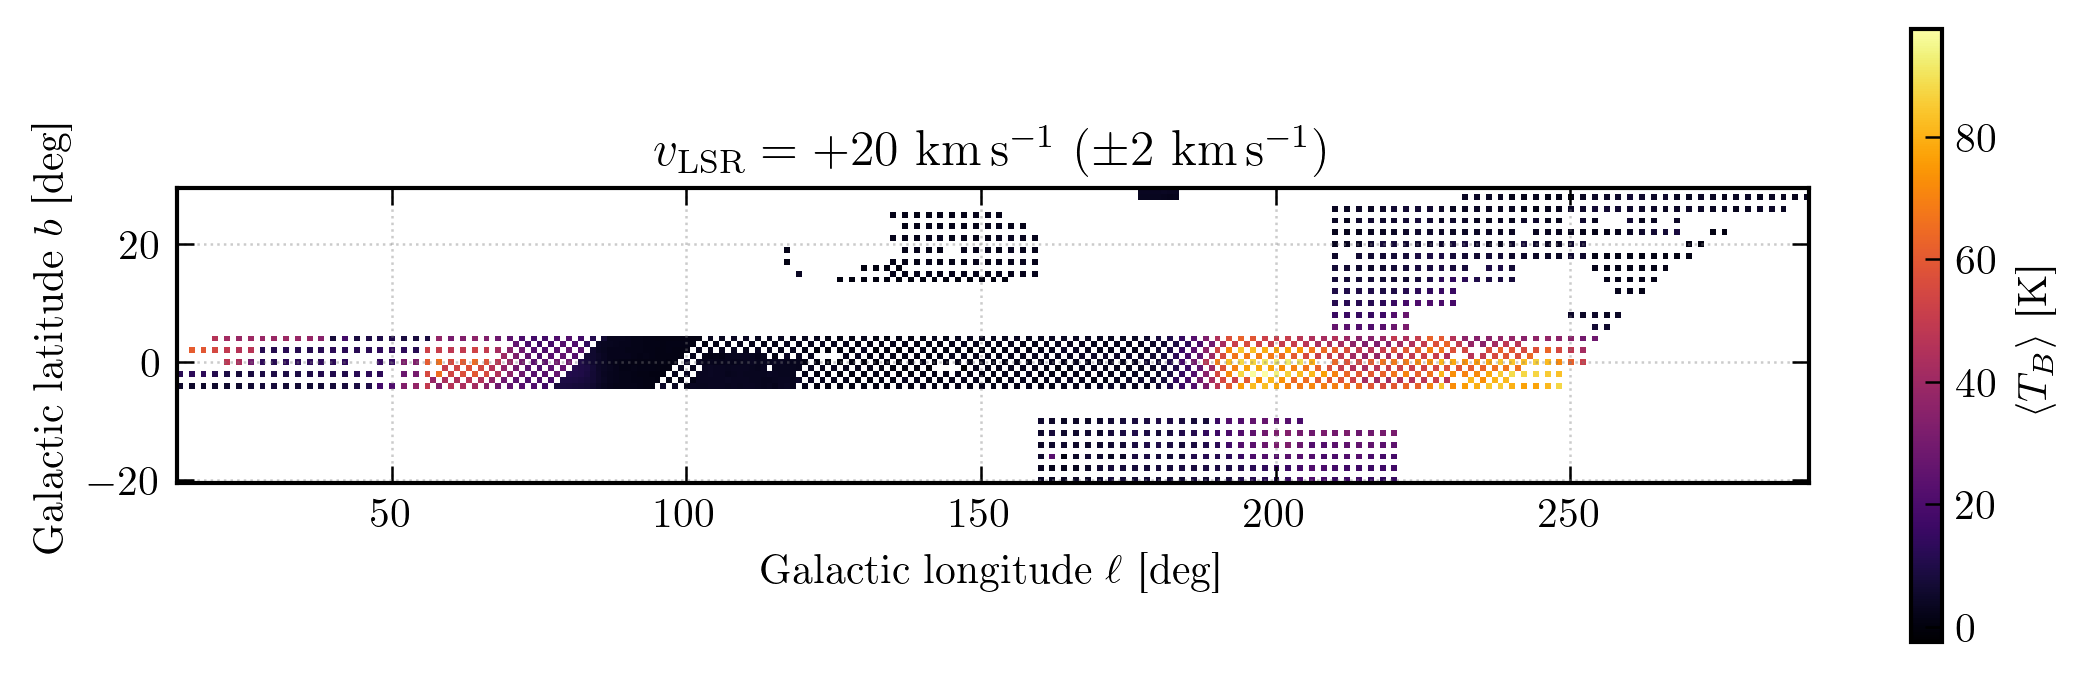

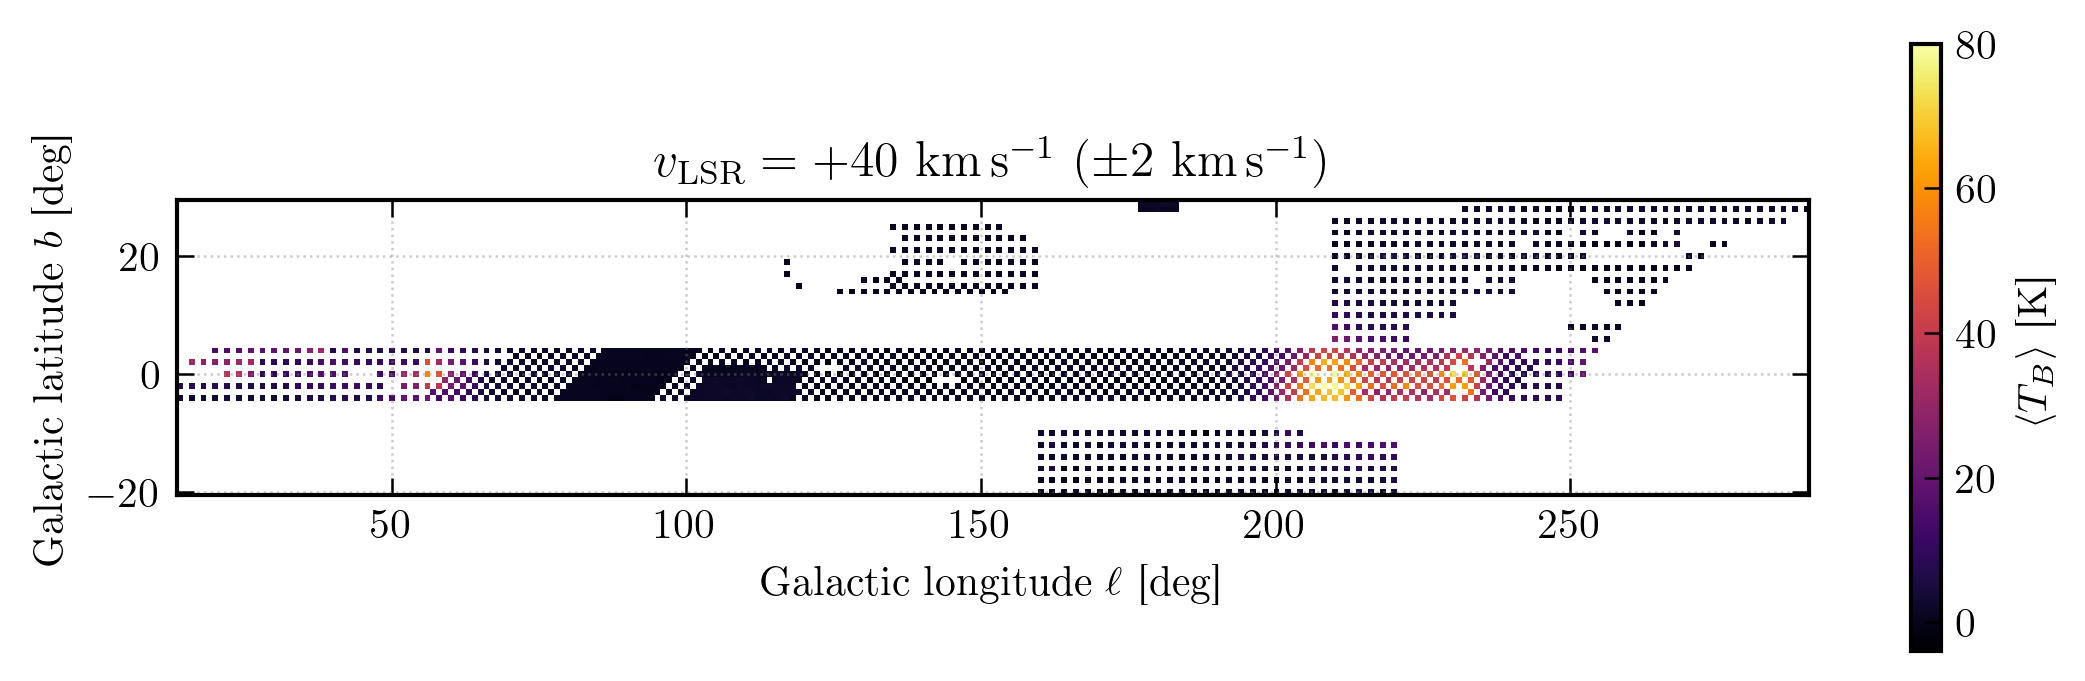

In [30]:
# --- Channel maps ---
v_slices_kms = [-60, -40, -20, 0, 20, 40]

for v_target in v_slices_kms:
    v_window = 5.0
    ch_mask = (v_lsr_overlap >= v_target - v_window / 2) & \
              (v_lsr_overlap <= v_target + v_window / 2)
    if ch_mask.sum() == 0:
        continue

    T_slice = np.nanmean(TB_stack[clean][:, ch_mask], axis=1)

    fig, ax = plot_heatmap(
        gl_arr[clean], gb_arr[clean], T_slice,
        cbar_label=r'$\langle T_B \rangle$ [K]',
        cmap='inferno',
        title=rf'$v_{{\mathrm{{LSR}}}} = {v_target:+d}$ km\,s$^{{-1}}$ '
              rf'($\pm${v_window/2:.0f} km\,s$^{{-1}}$)',
    )
    plt.show()